In [1]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.insert(0, './src')


from discipline_stats import (
    TestResults,
    filter_league_season,
    compare_two_groups,
    compare_mean_to_threshold,
    team_summary,
    venue_summary,
    plot_distribution,
    plot_boxplot,
    plot_home_away_distribution,
    plot_league_bar,
    plot_forest,
    check_normality,
    test_home_away,
    test_team_vs_rest,
    test_all_teams,
    compare_two_teams,
    rate_summary
)

from hypothesis_tests import (
    compute_team_stats,
    proportion_tests, # for z-test
    dispersion_check,
    bootstrap_test,
    mannwhitney_test,
    run_pipeline,
    plot_bootstrap_grid
)


with open('./data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

with open('./data/raw/european_leagues_data.pkl', 'rb') as f:
    all_matches = pickle.load(f)

print('Import successful')
print(f'team_matches shape: {team_matches.shape}')

Import successful
team_matches shape: (53386, 20)


In [3]:
def get_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_df = df[mask].copy()
    outlier_arr = outlier_df[col].to_numpy()

    return outlier_df, outlier_arr

In [4]:
# Leagues Dataset

df_serie_a = all_matches['Serie_A']
df_premier_league = all_matches['Premier_League']
df_la_liga = all_matches['La_Liga']
df_bundesliga = all_matches['Bundesliga']

# Latest year dataset

ita_2526 = df_serie_a[df_serie_a['season'] == '2526']
eng_2526 = df_premier_league[df_premier_league['season'] == '2526']
esp_2526 = df_la_liga[df_la_liga['season'] == '2526']
ger_2526 = df_bundesliga[df_bundesliga['season'] == '2526']

In [5]:
# all matches dataset for Serie A and Premier League season 24-25

all_matches_serie_a_2425 = filter_league_season(all_matches['Serie_A'], None, '2425')
all_matches_serie_a_2526 = filter_league_season(all_matches['Serie_A'], None, '2526')
all_matches_premier_league_2425 = filter_league_season(all_matches['Premier_League'], None, '2425')

all_matches_serie_a_2425['total_fouls'] = all_matches_serie_a_2425['HF'] + all_matches_serie_a_2425['AF']
all_matches_premier_league_2425['total_fouls'] = all_matches_premier_league_2425['HF'] + all_matches_premier_league_2425['AF']

all_matches_serie_a_2425['total_ycards'] = all_matches_serie_a_2425['HY'] + all_matches_serie_a_2425['AY']
all_matches_serie_a_2526['total_ycards'] = all_matches_serie_a_2526['HY'] + all_matches_serie_a_2526['AY']

# L'Inter e gli Outlier

## Premessa

Questo notebook sara' pieno di premesse, mani avanti e tanti tentativi di spiegare, in maniera intuitiva, concetti che stanno entrando nel lessico comune ma che spesso possono procurare fraintendimenti su come si interpretano. 

La premessa piu' importante, per quanto mi riguarda, parte da un fatto personale. Ho un Dottorato di Ricerca in Scienze Computazionali e Informatiche e la mia tesi di dottorato non sarebbe stata mai scritta se non ci fosse stato l'aiuto determinante del Professore Bruno Siciliano e del suo Prisma Lab. Spesso non riconosciamo i colpi di fortuna che ci capitano nella vita, uno di questi e' stata la possibilita' di poter conoscere il professor Siciliano e, per un breve periodo, addirittura aver collaborato con il suo gruppo. 

Detto questo, quando qualcuno tira in ballo i fatti citando numeri e statistiche, mi incuriosisco e cerco di capire su quali fatti si possano basare alcune affermazioni. E vista la stima e riconoscenza che ho verso il professor Siciliano, sono stato attirato da un titolo della testata tuttonapoli.net che citava ["Prof. Siciliano: "5 punti recuperati all'Inter, ma c'e' un rimpianto. E' stato uno scandalo!"](https://www.tuttonapoli.net/radio-tutto-napoli/prof-siciliano-5-punti-recuperati-all-inter-ma-c-e-un-rimpianto-e-stato-uno-scandalo-639256). Riporto dall'articolo una frase:

> **Ci sono anche dati statistici su questo tema?** 
> "Si, le statistiche dicono che l'Inter e' la squadra con meno cartellini gialli e 
> meno cartellini rossi. 
> La statistica piu' interessante e' il rapporto tra numero di falli fatti 
> e cartellini distribuiti: 
> mentre il valore medio e' un cartellino ogni quattro falli, 
> l'Inter prende un cartellino giallo ogni otto falli e mezzo. I numeri non mentono".

Ascoltando poi il podcast, il professor Siciliano cita anche che il dato sarebbe un "outlier".  A questo punto, la mia coda di avvocato del diavolo ha iniziato a scodinzolare (si, sono un diavolo avvocato del diavolo. Ad alcuni di noi diavoli e' stata data la possibilita' di scegliere tra le corna e la coda, e ho pensato che la coda fosse piu' facile da nascondere e potesse anche essere piu' utile in alcune situazioni) e mi sono messo alla ricerca dei dati che potessero confermare l'affermazione del professore.

Quando si fa un'analisi dati e si studia un'affermazione, per quanto banale possa sembrare, prima di tutto si parte dall'affermazione stessa. Sia il podcast che il testo riportato non sono univocamente precisi, come ci si aspetta da un'intervista che ha carattere generale e non specifico, e quando si parla di falli fatti e cartellini distribuiti non e' univoco ma almeno abbiamo un punto di partenza: ***"l'Inter prende un cartellino giallo ogni otto falli e mezzo mentre il valore medio e' un cartellino ogni quattro falli"***. 

Dato che a me piace partire facile, allora mi sono concentrato su uno studio abbastanza semplice: il rapporto tra cartellini ricevuti e falli fatti. "Partire facile" e' sempre relativo, dato che anche un obiettivo che sembra lineare e semplice porta alcuni caveat. Nell'analisi dati, o Data Science, vige la regola zero che e' "garbage in, garbage out": se si fa un'analisi con dati che non sono buoni o non ben definiti, il risultato sara' spazzatura. Aggiungo che spesso le analisi dei dati, i modelli che si introducono, amplificano il risultato e anche dei dati parzialmente sbagliati o non attinenti, possono venire amplificati nelle conclusioni che risulteranno quindi piu' simili a una discarica che a un bidone dell'immondizia.

E a questo punto, c'e' un'altra premessa e mi piace chiarirla dall'inizio. Il vero scopo di questo notebook non e' dare ragione al Professor Siciliano o meno, ma di propormi come il Barbero dell'Analisi Dati, ossia quello che, con fare bonaccione, ti spiega le cose facendoti appassionare su di un argomento del quale, 10 minuti prima, non ti interessava per nulla, tipo la forma delle maniglie nella Firenze dei Medici, e dopo averlo ascoltato ti metti il monocolo e cambi tutte le porte di casa. Ma, a differenza di Barbero, io parlero' di concetti matematici e statistici e, me ne rendo conto, sono argomenti che e' difficile rendere entusiasmanti. Nei prossimi paragrafi scrivero' di cose che, personalmente, trovo interessanti, divertenti, esaltanti ma gia' so che la maggior parte delle persone rimarra' esaltata come a un congresso di Potere al Popolo (un saluto a tutti gli amici di Potere al Popolo). Eppure nel calcio si parla tanto di statistica, di dati e ho il sospetto che spesso si faccia finta di capire. Per cui l'obiettivo finale di questo articolo sara' principalmente spiegare in termini quanto piu' semplici, ma accurati scientificamente, alcuni concetti di base che spesso sento in conversazioni e articoli sul calcio.

Ultima premessa, valida per tutto l'articolo: usero' semplificazioni volute per non appesantire la lettura. Gli esperti troveranno qualche imprecisione di linguaggio o qualche scorciatoia. Lo so, ne sono consapevole e l'ho fatto apposta. Dove la scorciatoia poteva indurre in errore, lo segnalo; altrove, tiro dritto.

## Un outlier non e' una vibrazione

Se si ascolta l'intervista al professor Siciliano, a un certo punto viene menzionato il termine "outlier". Un outlier, per definizione statistica, e' un dato che *differisce significativamente* dagli altri dati osservati. Ci possono essere diverse cause per un outlier e, in genere, quando si fa uno studio statistico dei dati, uno dei primi passi e', appunto, cercare gli outlier nei dati. Non esiste un'unica definizione universalmente accettata di cosa renda un dato un outlier, ma ci sono metodi operativi precisi per individuarli. Quello piu' usato e' quello che si basa sul cosiddetto Scarto Interquartile: ossia la differenza tra il primo e il terzo quartile (Il primo quartile viene indicato con Q1, il terzo con Q3.). Si definiscono outlier i valori che cadono al di sotto del primo quartile meno *k* volte questa differenza, oppure al di sopra del terzo quartile piu' *k* volte la stessa differenza. Il valore standard di *k* e' 1.5, proposto da John Tukey negli anni '70, e corrisponde approssimativamente a escludere i valori oltre 2.7 deviazioni standard dalla media in una distribuzione normale. Il quartile non e' il concetto piu' elettrizzante del mondo e, in breve, lo si puo' vedere come le porzioni di dati che contengono un quarto delle osservazioni una volta ordinate. Prima di tutto guardiamo come sono distribuiti i dati attraverso un istogramma, poi useremo il box-plot per visualizzare quartili e outlier.  

Dato che stiamo parlando del numero di falli fischiati in una partita, prendiamo ad esempio i dati relativi a tutte le partite giocate nel campionato di Serie A dalla stagione 2011/12 fino a fine marzo 2026, oltre 5000 partite, e consideriamo il numero di falli commesso dalla squadra che giocava in casa. Ci saranno partite nelle quali l'arbitro avra' fischiato pochi falli, altre nelle quali il numero e' stato elevato. Contiamo ora il numero di partite nelle quali sono stati fischiati, alla squadra di casa, $x$ numero di falli e costruiamo l'istogramma dei dati.    

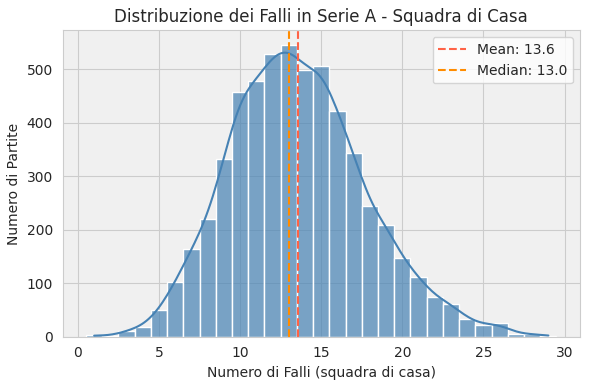

In [6]:
# Plot Serie A total fouls distribution
fig, ax = plot_distribution(df_serie_a, 
                            'HF',
                            title = 'Distribuzione dei Falli in Serie A - Squadra di Casa',
                            figsize=(6,4),
                            xlabel = 'Numero di Falli (squadra di casa)',
                            ylabel= 'Numero di Partite',
                            discrete=True)

L'asse $x$ dell'istogramma rappresenta il numero di falli fischiati alla squadra di casa, l'asse $y$ il numero di partite dove quel numero di falli e' stato registrato. L'istogramma dei dati ci dice, ad esempio, che in oltre 500 partite, il numero di falli fischiati alla squadra di casa e' stato di 13. Se andiamo a contare il numero di partite in cui sono stati fischiati 5 falli, approssimativamente abbiamo meno di 50 partite; partite nelle quali sono stati fischiati 25 falli sono ancora piu' rare, dal grafico direi che siamo nell'ordine di una ventina. L'istogramma ci visualizza la distribuzione dei dati (ci sono delle ragioni per le quali la forma della distribuzione ci sembra familiare e alcune di queste ragioni sono il motivo per il quale il calcio e' cosi' seguito e amato. Dettagli in seguito), ma poco ci dice su quali siano gli outlier, ossia i valori che si discostano significativamente dal comportamento centrale dei dati, secondo la definizione che abbiamo dato prima. Il box-plot lo visualizza meglio: 

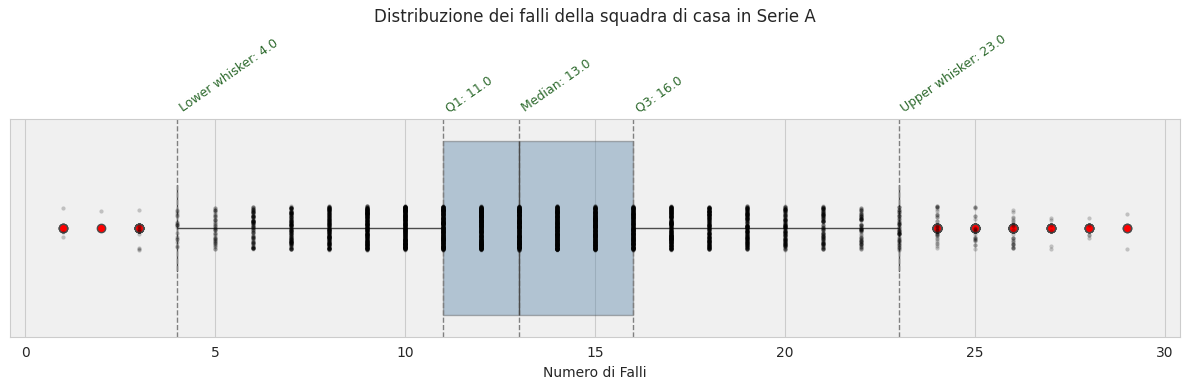

In [7]:
plot_boxplot(df_serie_a, column = 'HF', 
             title="Distribuzione dei falli della squadra di casa in Serie A",
             figsize=(12, 4),
             xlabel='Numero di Falli', 
             ylabel='');

Il box-plot ci visualizza intuitivamente alcuni dei concetti che ho introdotto precedentemente. Q1 e Q3 sono il primo e terzo quartile, e in blu e' visualizzata la parte di dati contenuta tra queste due fette. I whisker inferiore e superiore sono quelli ottenuti moltiplicando 1.5 volte la differenza e, in parole povere, ci dicono dove la stragrande maggioranza di dati si trova. In rosso sono evidenziati, appunto, gli outlier di questa distribuzione. Ci dicono che al di sotto di 4 falli e al di sopra di 23 falli si sono registrati gli "eventi eccezionali", ossia che si discostano di molto da quello che e' il comportamento generale sul numero di falli.

In [8]:
outliers_hf, list_outliers = get_outliers(df_serie_a,
             'HF')

print(f" Numero di outlier: {outliers_hf.shape[0]}, rappresentano il {outliers_hf.shape[0] / df_serie_a.shape[0] * 100:.2f}% del totale.")

 Numero di outlier: 109, rappresentano il 1.94% del totale.


Quindi su oltre 5000 partite, 109 rappresentano dei dati anomali (spesso il concetto di outlier e anomalie viene usato in maniera interscambiabile). E in effetti, a volte questi dati anomali possono nascondere dei problemi. Studiando proprio il numero di falli commesso in una partita, ho esteso il controllo a tutti i campionati nel dataset, e mi sono imbattuto su quattro partite in cui non era stato fischiato nemmeno un fallo a una delle due squadre. Le partite sono:

- [Chelsea - West Ham](https://www.espn.co.uk/football/matchstats/_/gameId/541714)
- [Wolves - Brighton](https://www.espn.co.uk/football/matchstats/_/gameId/513490)
- [Malaga - Real Sociedad](https://www.espn.co.uk/football/matchstats/_/gameId/490376) 
- [Lille - Rennes](https://www.espn.com/soccer/matchstats/_/gameId/609158) 

Andando a controllare sul sito di espn, ho effettivamente riscontrato che nelle prime 3 partite, una delle due squadre non aveva commesso neanche un fallo (o meglio, non era stato fischiato o registrato alcun fallo). Nella partita Malaga-Real Sociedad, inoltre, la squadra ospite non aveva commesso nessun fallo e aveva anche ricevuto un cartellino giallo (per perdita di tempo). Solo Lille-Rennes ha evidenziato un errore nei dati riportati dal sito football-data.co.uk laddove espn riporta un numero di falli superiore. 

Quindi lo studio degli outlier ha evidenziato che avere partite nelle quali non si fischiano falli a una delle due squadre sia possibile. Improbabile, ma possibile. E anche ha evidenziato un errore nella rilevazione dei dati.

Volendo riassumere, possiamo definire gli outlier come anomalie, dati che si discostano di parecchio da quello che e' il comportamento degli altri dati. Non sempre sono errori nella rilevazione, e, anzi, sono spesso casi rarissimi ma reali. Voglio precisare che, comunque, il "parecchio" e' qualcosa che decidiamo noi una volta che usiamo il metodo per rilevare gli outlier, che puo' cambiare a seconda della distribuzione e dal tipo di analisi che vogliamo condurre. Il numero di outlier dipende da come sono distribuiti i dati: nel caso del numero di falli, abbiamo trovato 109 outlier su oltre 5000 partite, circa il 2%. In altre distribuzioni la percentuale cambia, ma rimane sempre una frazione piccola del totale (altrimenti non sarebbero outlier).

## Falli e cartellini

L'affermazione che vogliamo studiare parla di falli commessi e cartellini gialli ricevuti. Dal punto di vista colloquiale, nella cornice di un intervista a una testata calcistica, o nel gergo del bar dello sport, l'affermazione e' chiara e cristallina: una squadra commette un tot numero di falli e riceve un certo numero di cartellini gialli o rossi. Anche se la maggior parte di noi dormiva durante le lezioni di matematica a scuola, abbiamo tutti in mente che queste due quantita', falli e cartellini, sono correlate nel senso che piu' commetto falli e piu' mi aspetto che cresca il numero di cartellini. La nostra mente pragmatica e il buon senso, ci dice anche che se guardiamo nel lungo periodo, ossia senza fermarci alla singola partita ma prendendone tante, e le condizioni sono uguali per tutti (specie gli arbitraggi), allora bene o male il numero di cartellini ricevuti sara' proporzionale al numero di falli commessi e questa proporzione, sempre nell'ottica di un arbitraggio neutrale, deve essere bene o male uguale per tutti. Il nostro buonsenso, la nostra intuizione, ci porta anche a dire che possiamo accettare che la proporzione non sia uguale per tutti ma che possano esserci degli scostamenti tra una squadra e un'altra, del resto anche quando ordiniamo due etti di prosciutto dal salumiere non ci aspettiamo che siano perfettamente 200 grammi e siamo disposti a pagare la differenza - esistono teoremi matematici (li ho dimostrati io ma mai pubblicati E DIMOSTRAMI CHE NON E' VERO!!!11!!!) che dimostrano che le mani dei salumieri hanno una taratura del peso nettamente diversa dagli strumenti che misurano e il peso che loro valutano e' sempre sottostimato rispetto a quello riportato dalla bilancia. Solo che una volta che hai affettato 300 grammi, che fai, li rimetti indietro?. Eppure il nostro buonsenso ci porta a fare delle ipotesi matematiche che, anche se non ce ne accorgiamo, sono ben lontane dall'essere dei principi universali e, anzi, proprio in linea di principio dal punto di vista matematico e fisico queste ipotesi proprio non sussistono. 

In primo luogo, un fallo commesso e' gia' diverso da fallo fischiato. Non tutti i falli commessi vengono fischiati, sia perche' nel calcio c'e' la regola del vantaggio, sia perche' non tutti i falli vengono visti e sanzionati dall'arbitro ("sanzionato dall'arbitro" e' una frase automatica di ognuno di noi che segue il calcio, e vuole scrivere un articolo, prima o poi la scrive. E' come il verbale dei carabinieri pieno di locuzioni proprie quali "mi apprestavo ad avvicinarmi al luogo preposto all'imbarco del servizio di mobilita' cittadina" invece di scrivere "stavo per prendere l'autobus").

Sulla correlazione tra cartellini gialli e falli commessi, un primo aspetto che gia' non stiamo includendo e' il fatto che un cartellino giallo possa essere dato da un arbitro senza che sia stato fischiato un fallo. Ad esempio, quando si commina (altro termine proprio dei cartellini gialli) un cartellino per proteste o per perdite di tempo, potrebbe essere stato addirittura fischiato in precedenza un fallo a favore.

Ma un aspetto ancora piu' sofisticato, e' il fatto che, inconsciamente, trattiamo i falli commessi e i cartellini comminati come eventi a se indipendenti, ossia che due falli consecutivi o due ammonizioni consecutive siano eventi statisticamente indipendenti gli uni dagli altri. E questa e' una bella ipotesi, forte, che andrebbe se non altro dimostrata.  

In sintesi: quando vogliamo eseguire un'indagine statistica seria su falli e cartellini, ognuna di queste assunzioni va tradotta in un corrispettivo matematico nei modelli e nei test che usiamo. 

Torniamo un attimo a quanto dichiarato nell'intervista e partiamo dalle cose semplici e ci chiediamo quanti falli sono stati fischiati nel campionato italiano di quest'anno e come sono distribuiti.

### Partiamo dalle basi: i falli

Partiamo da una domanda semplice: quanti falli si fischiano in una tipica partita di serie A? 

Ogni partita e' diversa dalle altre, le squadre che si affrontano hanno motivazioni che dipendono da quella singola partita e che sono diverse a seconda della loro forza, la posizione in classifica, se giocano in casa o in trasferta, insomma, tutti fattori che rendono le partite di quella giornata e di tutte le altre giornate indipendenti le une dalle altre: ognuna e' particolare, ognuna e' diversa dall'altra. Ovviamente, ci sono fattori che possono influenzare il modo in cui due squadre che giocano una partita che dipendono da altre partite: il risultato di una concorrente puo' influenzare la tattica e le motivazioni, quindi una totale indipendenza non c'e'.

Fatta questa ovvia premessa, nel campionato italiano 2024/25, quanti falli sono stati fischiati in ogni partita? A partire dai dati sulle singole partite che abbiamo, andiamo a costruirci l'istogramma dei falli fischiati per ogni partita, ossia contiamo il numero di falli fischiati per ogni partita e vediamo in quante partite sono state commessi 30 falli, quante 35 e cosi' via.  

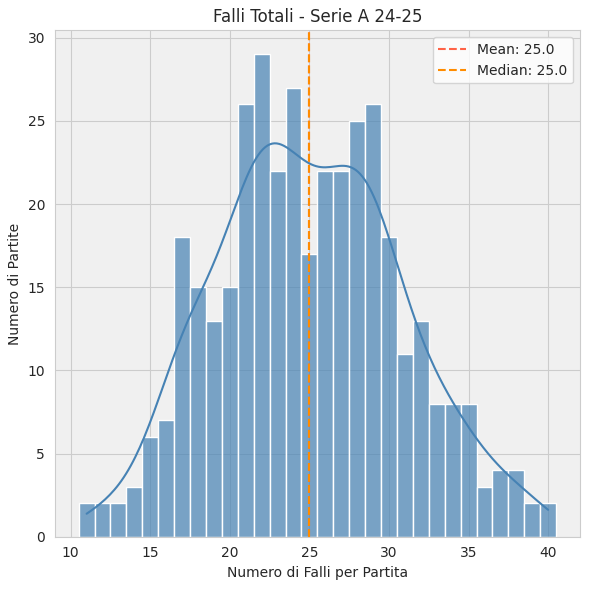

In [9]:
# Plot Serie A total fouls distribution
fig, ax = plot_distribution(all_matches_serie_a_2425, 
                            'total_fouls',
                            title = 'Falli Totali - Serie A 24-25',
                            figsize=(6,6),
                            xlabel = 'Numero di Falli per Partita',
                            ylabel= 'Numero di Partite',
                            discrete=True)

In [10]:
all_matches_serie_a_2425['total_fouls'].describe()

count    380.000000
mean      25.002632
std        5.793500
min       11.000000
25%       21.000000
50%       25.000000
75%       29.000000
max       40.000000
Name: total_fouls, dtype: float64

L'istogramma che risulta dai dati assomiglia a quella che si chiama una distribuzione normale: la maggior parte delle partite hanno un numero di falli che varia tra i 20 e i 30 e i dati sembrano abbastanza simmetrici: a destra e a sinistra della media, il numero di partite con piu' o meno falli e' piu' o meno lo stesso. Volendo essere ancora piu' analitici, sembra quasi che ci siano due distribuzioni, con due picchi a sinistra e a destra della media, che si fondono assieme. 

### Il modello e la realta'. 

Quando, in statistica come in fisica, parliamo di un modello, parliamo sempre di un'approssimazione della realta'. Quando dico che la distribuzione assomiglia a una "distribuzione normale", la sto approssimando a un modello che e', esso stesso, un'approssimazione della realta'. Quanto buona sia questa approssimazione, tanto piu' posso trarre delle conclusioni sui dati ragionevoli ed entro un determinato margine di errore. Dal punto di vista statistico, vista la distribuzione dei dati, posso supporre che se li modello come una distribuzione normale l'errore non sara' enorme.

Faccio un esempio pratico. Nella stagione 2024/25 la media per partita del numero di falli fischiati e' stata di circa 25 con una deviazione standard, ossia lo scostamento dalla media di quasi 6 falli. In termini pratici, diremmo che in ogni partita sono stati fischiati 25 falli piu' o meno 6. Media e deviazione standard li ho ricavati dai dati reali, empirici. A questo punto, dico che i dati si distribuiscono come una Gaussiana (o Normale) con valore medio di 25 e deviazione standard di 6. Se interrogo il modello cosi' costruito, senza andare a contare i dati reali, saro' in grado di fare previsioni. Ad esempio, posso chiedermi quale sia la probabilita' che, in una partita ipotetica, l'arbitro fischi piu' di 30 falli. Se uso il modello gaussiano, la risposta sara' di: 

In [11]:
from scipy import stats

p = 1 - stats.norm.cdf(30, 
                       loc=all_matches_serie_a_2425['total_fouls'].mean(), 
                       scale=all_matches_serie_a_2425['total_fouls'].std())
print(f"P(X >= 30) = {p:.4f}")

P(X >= 30) = 0.1942


Il modello ci dice che questa probabilita' e' di circa il 20%. Se ora andiamo a contare sulle 380 partite, quante ce ne sono state con 30 o piu' falli e ne calcoliamo la frazione otterremo: 

In [12]:
n_fouls = 30
total_matches = all_matches_serie_a_2425.shape[0]
n_matches = all_matches_serie_a_2425[all_matches_serie_a_2425['total_fouls'] >=n_fouls].shape[0]
print(f"Numero di partite con almeno 30 falli: {n_matches}")
print(f"Frazione di partite con almeno 30 falli: {n_matches/total_matches:.4f}")

Numero di partite con almeno 30 falli: 81
Frazione di partite con almeno 30 falli: 0.2132


Il modello dice che la probabilita' e' di circa il 20%, la realta' mi dice che la frazione di partite con 30 o piu' falli rispetto al totale e' di poco piu' del 21%, meno del 2% di errore tra valore ottenuto con il modello rispetto al dato reale. Sta a noi decidere se questo margine di errore sia accettabile o meno, e dipende dal tipo di analisi o di precisione che vogliamo ottenere. Possiamo migliorare il modello e ottenere risultati piu' precisi, ma ogni volta che miglioriamo un modello, e quello normale e' tra i piu' semplici, andiamo a pagare un costo che puo' essere in termini di complessita' di calcolo, di interpretabilita, di quanto tempo ci metto a calcolare tutto. Alla fine della fiera, se modelliamo i dati del numero di falli fischiati come un modello normale, non ci allontaniamo di molto dalla realta' e possiamo anche rispondere a domande interessanti fidandoci delle risposte del modello probabilistico. 

Ad esempio, se volessimo confrontare il numero di falli fischiati in Serie A nel campionato di calcio 2024/25 con quelli del campionato Inglese nella stessa stagione, possiamo dire qualcosa sulla loro differenza? Senza andare troppo per il sottile, andiamo subito a vedere come sono distribuiti i dati sui falli fischiati in Premier League per partita.

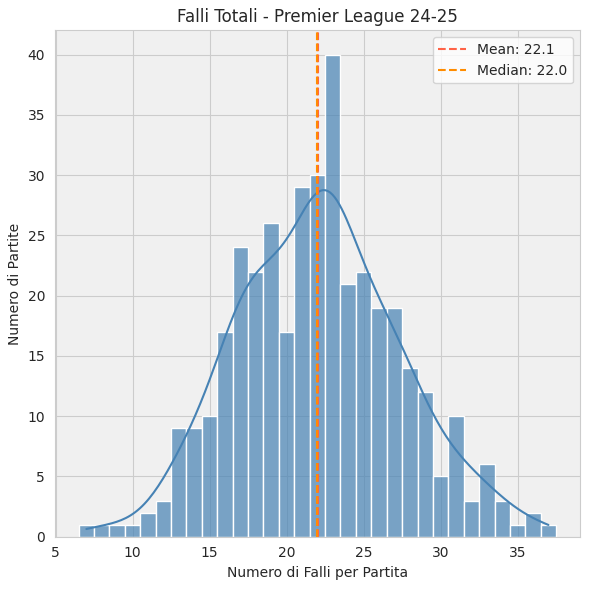

In [13]:
# Plot Premier League total fouls distribution
fig, ax = plot_distribution(all_matches_premier_league_2425, 
                            'total_fouls',
                            title = 'Falli Totali - Premier League 24-25',
                            figsize=(6,6),
                            xlabel = 'Numero di Falli per Partita',
                            ylabel= 'Numero di Partite',
                            discrete=True)

In [14]:
all_matches_premier_league_2425['total_fouls'].describe()

count    380.000000
mean      22.065789
std        5.271358
min        7.000000
25%       18.000000
50%       22.000000
75%       25.250000
max       37.000000
Name: total_fouls, dtype: float64

Due campionati diversi, la stessa forma per la distribuzione ma media e mediana diverse: nel campionato italiano la media e' di circa 25 falli fischiati a partita, nel campionato inglese circa 22 (con una deviazione standard di circa piu' o meno cinque falli a partita). Questa differenza e' "statisticamente significativa"? Quando si parla di differenza "statisticamente significativa", facciamo riferimento al fatto che, come abbiamo visto, i valori medi che descrivono una misura hanno un margine di errore che possiamo attribuire al caso. Come abbiamo detto all'inizio, ogni partita e' un caso a se stante, ci sono tantissime variabili in gioco e il risultato di una misura e' dettato molto dal caso e quindi si discostera' dal suo valore medio. Nel caso dei campionati italiano e inglese, le medie sono diverse e anche gli errori sono diversi. Se andiamo a visualizzare le due curve, ci saranno molte sovrapposizioni e quindi e' ragionevole chiedersi se la differenza che vediamo nei valori medi e' possibile attribuirla al caso, all'errore che entrambe le misure si portano dietro, o c'e' effettivamente una differenza strutturale che non dipende dall'aleatorieta' delle partite? Per questo, ci si serve di test statistici, e i test statistici dipendono da come modelliamo le distribuzioni.

Se ora ipotizziamo che entrambe le distribuzioni dei dati siano normali, ci sono test statistici che ci permettono di dire, appunto, se le medie sono effettivamente diverse. I piu' famosi sono i t-test di [Student](https://en.wikipedia.org/wiki/Student%27s_t-test) e [Welch](https://en.wikipedia.org/wiki/Welch%27s_t-test). Il test di Student parte dal presupposto che le due misure (popolazioni) che stiamo confrontando siano distribuite normalmente (ossia gaussianamente) e abbiano uguale varianza. Il test di Welch considera il fatto che le due distribuzioni siano ancora normali, ma abbiano diversa varianza. 

E a questo punto parte il momento Barbero.

Se pensate che la probabilita' e la statistica siano nate, come discipline scientifiche, dalla mente di brillanti matematici che cercavano di dimostrare l'esistenza di dio facendone una questione di interrogare il caso, confrontarle con l'esperienza fisica e tirar fuori modelli complessi che potessero parlare dell'iperuranio, avete in parte ragione. Una parte molto piccola. Il calcolo della probabilita' nasce con [Gerolamo Cardano](https://en.wikipedia.org/wiki/Gerolamo_Cardano), un astrologo e giocatore d'azzardo, e con due tra le piu' brillanti menti matematiche di ogni tempo: [Pierre de Fermat](https://en.wikipedia.org/wiki/Pierre_de_Fermat) e [Blaise Pascal](https://en.wikipedia.org/wiki/Blaise_Pascal). A Cardano si deve il primo libro che parla dei giochi basati sul caso (il Liber de ludo aleae), nel quale descrive i giochi cercando di spiegarli (e capirli) in termini di quale sia la probabilita' di vincere ai giochi. Ah, anche barando. Cardano, nel libro, spiega anche i trucchi per barare. E se vi chiedete se questo brillante matematico fosse poi in grado di vincere, sappiate che Cardano, per tutta la sua vita, lotto' contro debiti e cambiali a causa del suo modo di giocare. E se, come me, avete un senso dell'umorismo discutibile, troverete divertente anche la storia dei suoi figli. Per quanto riguarda Fermat e Pascal, dovrebbe anche essere inutile sottolineare il contributo che hanno dato al progresso scientifico. Entrambi vissuti nel '600, il loro contributo e' ancora oggi usato in ambito scientifico e le loro teorie vengono usate in campi come la matematica, la fisica, l'economia e tante applicazioni pratiche anche oggi all'avanguardia. Due che non perdevano tempo a vedere serie su Netflix, insomma. Pascal ancora oggi e' visto come un pensatore influente in ambito religioso. E quindi, quando corrispondeva con Fermat e assieme costruivano le fondamenta del calcolo probabilistico, di cosa parlavano? Parlavano di gioco d'azzardo. Di quale fosse il modo corretto di valutare le scommesse e di come si potesse capire se si potesse avere un vantaggio statistico nei giochi d'azzardo. Tra parentesi, gli stessi principi che Pascal trasse dalla corrispondenza con Fermat, li uso' per provare l'esistenza di dio. E se vi chiedete se alla fine del loro carteggio, avessero trovato la soluzione per vincere al gioco d'azzardo, la risposta la da la vita del [Cavaliere de Mere](https://en.wikipedia.org/wiki/Antoine_Gombaud), ossia quello che aveva consultato i due scienziati per avere la risposta. La risposta e' no. 

Questo per quanto riguarda le origini del calcolo della probabilita', e allora i test di ipotesi per cosa nascono? Questo famoso t-test di Student per capire se la media di due popolazione e' statisticamente la stessa o diversa, per cosa nasce? Dalla birra. La Guinness, per essere precisi. Il test di Student e' stato sviluppato da [William Sealy Gosset](https://en.wikipedia.org/wiki/William_Sealy_Gosset), uno statistico e chimico che lavorava, appunto, per la Guinness e il cui lavoro era controllare la qualita' della birra. Il test si chiama di Student perche' quando Gosset pubblico' l'articolo che lo descriveva, non poteva usare il suo nome dato che lavorava per un privato che si preoccupava di non far conoscere i loro segreti industriali in giro. Gosset, allora, si dovette firmare con uno pseudonimo (leggenda vuole che lo scelse per quello che era: uno student, e da li il test di Student). E se credete mi sia inventato questa storia, no e' tutto vero. Quindi, i test statistici che oggi vengono usati per testare medicine, vaccini e tante altre cose, sono nati per migliorare la produzione di birra (per la scelta dello pseudonimo non ci sono certezze ma mi piace pensare sia andata cosi'). 

Birra e gioco d'azzardo. Se non riuscite ad appassionarvi a un tema che parte da queste premesse, non so cosa possa appassionarvi.

Finito il nostro momento Barbero, torniamo all'applicazione del test nel nostro caso (siamo passati dalla birra al calcio e quindi la continuita' narrativa e' assicurata). Vogliamo sapere se le due medie siano diverse, ma dal punto statistico partiamo invece dal chiederci quale sia la probabilita' che le due medie siano uguali: e' la famosa Ipotesi Zero, Ipotesi Nulla, Null Hypothesis chiamiamola come vogliamo noi, quella e'. I test statistici funzionano bene o male tutti cosi. Si sceglie innanzi tutto una soglia di significanza statistica detta $\alpha$. Si confrontano poi le due medie e i loro rispettivi errori statistici e ci si chiede, sotto l'ipotesi che le due medie siano uguali, qual e' la probabilita' di osservare uno scostamento tra le medie cosi' estremo da quello registrato? Detto in altre parole, se partiamo dal presupposto che le medie sono uguali, qual e' la probabilita' di osservare poi con i dati una differenza cosi' grande? Questa probabilita' si chiama p-value. A questo punto si confronta il p-value con la soglia di significanza statistica e:

- se il p-value e' maggiore della soglia $\alpha$, allora non c'e' significanza statistica e non riesco a scartare l'ipotesi che le due medie siano le stesse ma differiscano solo "per caso"
- se il p-value e' minore della soglia, allora il fatto che le due medie siano le stesse e la differenza sia solo un caso diventa difficile da sostenere e allora mi devo cercare un'ipotesi alternativa a quella che mi dice che le medie sono uguali

Ho tralasciato, in questa spiegazione, parecchie sottigliezze matematico-filosofiche (che in effetti sottigliezze non sono) e mi sono tenuto lontano dal gergo tecnico e gia' molte cose sembrano complicate senza spiegazione. Ad esempio, perche' scegliere una soglia $\alpha$ e non andare direttamente a guardare il p-value e vedere quanto e'? Perche' la fatica di definire l'ipotesi zero in quel modo e non andare direttamente a vedere quanto siano diversi? Perche' non definire il p-value come la probabilita' dei dati e invece definirlo come la probabilita' di osservare una differenza cosi' estrema? Queste che sembrerebbero sottigliezze, non lo sono, ma sarebbe troppo lungo approfondirle in questo notebook.

Finalmente, vediamo se in Inghilterra e in Italia si fischiano piu' o meno falli. Iniziamo con Student.

In [15]:
serie_a_2425_fouls = all_matches_serie_a_2425['total_fouls']
premier_league_2425_fouls = all_matches_premier_league_2425['total_fouls']

t = compare_two_groups(serie_a_2425_fouls, 
                   premier_league_2425_fouls,
                   label_a='Serie A 24-25',
                   label_b='Premier League 24-25')

In [16]:
t.show('student_t')

Serie A 24-25 vs Premier League 24-25
--------------------------------------------------
  mean_Serie A 24-25        25.0026
  mean_Premier League 24-25 22.0658
  std_Serie A 24-25         5.7935
  std_Premier League 24-25  5.2714
  n_Serie A 24-25           380
  n_Premier League 24-25    380
  mean_diff                 +2.9368
--------------------------------------------------
  student_t                 stat=7.3090, p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  0.5303
  rank_biserial             -0.2846


Il test di Student mi dice che il p-value e' di 0.000 etc etc. ben al di sotto della soglia del 5% (o $\alpha = 0.05$). Quindi, se eseguiamo il test supponendo le distribuzioni dei falli fischiati in Inghilterra e in Italia come normali e con uguale varianza, la differenza tra le medie e' statisticamente significativa: non e' dovuta a fluttuazioni statistiche ma e' sistematica.

E se consideriamo il fatto che la varianza nelle medie italiane e inglesi e' diversa? Allora ci aiuta il test di Welch:

In [17]:
t.show('welch_t')

Serie A 24-25 vs Premier League 24-25
--------------------------------------------------
  mean_Serie A 24-25        25.0026
  mean_Premier League 24-25 22.0658
  std_Serie A 24-25         5.7935
  std_Premier League 24-25  5.2714
  n_Serie A 24-25           380
  n_Premier League 24-25    380
  mean_diff                 +2.9368
--------------------------------------------------
  welch_t                   stat=7.3090, p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  0.5303
  rank_biserial             -0.2846


La situazione non cambia: il valore del p-value e' ancora 0 (a non so quante cifre significative). Arrendiamoci e, sotto l'ipotesi di normalita' dei dati, possiamo tranquillamente affermare che in Premier League si fischiano meno falli per partita che in Serie A. E quindi arbitrare all'Inglese non e', almeno per quanto il numero di falli fischiati, una frase fatta ma ha, almeno per quanto riguarda il numero di falli, un fondamento statistico.

### OK, ma a questo punto l'Inter?

Siamo partiti con un'affermazione circa l'Inter e l'attuale campionato di Serie A e ci siamo costruiti degli strumenti statistici per confrontare dei dati (delle medie). Ora facciamo un piccolo passettino verso la risposta alla domanda principale andando a studiare i falli commessi dalle varie squadre nel campionato di calcio italiano nella stagione in corso (30 partite su 38, all'epoca dell'intervista) e vediamo come si colloca l'Inter nel panorama del resto delle squadre. Nel farlo, introduciamo altri elementi che ci aiuteranno a capire come si possa fare un'indagine statistica appropriata e migliore.

Nella sezione precedente, ci siamo concentrati sul numero di falli a partita nel campionato italiano 2024/25. Ora studiamo il ***numero di falli commessi per squadra*** nel campionato in corso e vediamo innanzi tutto qual e' la distribuzione dei falli commessi

In [18]:
all_matches_serie_a_2526 = filter_league_season(all_matches['Serie_A'], None, '2526')
all_matches_serie_a_2526['total_fouls'] = all_matches_serie_a_2526['HF'] + all_matches_serie_a_2526['AF']

print(all_matches_serie_a_2526.shape)

(300, 23)


In [19]:
ita_2526 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2526')
].copy()

dates = pd.to_datetime(ita_2526['date'], dayfirst=True)

print(f"Rows loaded: {len(ita_2526)}")
print(f"Matches played: {len(ita_2526) // 2}")
print(f"Teams: {ita_2526['team'].nunique()}")
print(f"Date range: {dates.min().strftime('%d/%m/%Y')} → {dates.max().strftime('%d/%m/%Y')}")

Rows loaded: 600
Matches played: 300
Teams: 20
Date range: 23/08/2025 → 22/03/2026


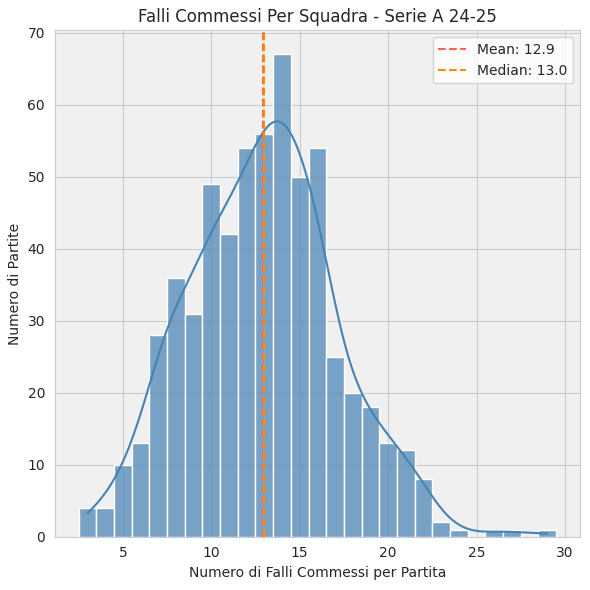

In [20]:
# Plot Serie A total fouls distribution
fig, ax = plot_distribution(ita_2526, 
                            'fouls_committed',
                            title = 'Falli Commessi Per Squadra - Serie A 24-25',
                            figsize=(6,6),
                            xlabel = 'Numero di Falli Commessi per Partita',
                            ylabel= 'Numero di Partite',
                            discrete=True)

Prima abbiamo studiato il numero di falli fischiato per partita in due campionati diversi e abbiamo visto una distribuzione approssimabile a una gaussiana. Ora ci concentriamo sul numero di falli commesso da ogni squadra per partita e, ancora, abbiamo una curva simile a una gaussiana. E anche in questo caso media e mediana sono molto simili (in genere e' segno di normalita'). Nel caso della stagione completa 24-25, avevamo un dataset di 380 partite e la curva sembrava meglio definita di questa che considera 300 partite: piu' dati abbiamo, meglio si definisce la forma dell'istogramma (non e' che la distribuzione diventa "piu' normale", e' che con piu' dati riusciamo a vederne meglio la forma). Ma perche' questa forma e' proprio una campana? Una possibile spiegazione ce la da' il Teorema del Limite Centrale (CLT): quando una grandezza e' il risultato della somma di tanti piccoli contributi indipendenti tra loro, la sua distribuzione tende a essere normale. In una partita di calcio, il numero totale di falli e' la somma di tanti micro-eventi: novanta minuti di gioco, ventidue giocatori in campo, decine di contrasti, ognuno dei quali puo' o meno essere fischiato come fallo. Se questi eventi sono ragionevolmente indipendenti l'uno dall'altro, il CLT ci dice che il totale tendera' a distribuirsi come una gaussiana. E' come se i falli di una partita di calcio seguissero le stesse regole di eventi totalmente indipendenti tra di loro, come nelle ipotesi del CLT. E guardate che, a ben vedere, non e' scritto da nessuna parte che il numero di falli sia qualcosa di cosi' casuale dato che stiamo parlando di un gioco che ha regole e tattiche. Ed e' qui che c'entra, secondo me, il successo di giochi come il calcio: l'imprevedibilita'. E non parlo solo dell'imprevedibilita' del risultato, ma di come il gioco si svolge e di come tutte le sue componenti, che dovrebbero comunque avere uno schema predefinito altrimenti non avremmo tutti questi allenatori che urlano non rispettando l'area tecnica e non fanno altro che indicare tutti i movimenti che i giocatori dovrebbero fare, interagiscano affinche' il risultato finale sia cosi' descritto dal caso. Eppure, in una partita di calcio un tiro, un fallo, un cartellino giallo sono fondamentalmente imprevedibili: il tifoso e' intento a comprare il suo caffe' borghetti e l'attaccante segna o viene falciato al limite dell'area di rigore. La distribuzione normale e' il modello probabilistico forse piu' semplice possibile, descritto solo da una media e una deviazione standard (quel e' il valore che si verifica piu' frequentemente e di quanto si varia da questo valore) che descrive il caso. O il caos, se vogliamo. Un caos che, eppure, ha una forma matematica estremamente elegante e semplice: una campana. 

Fatto uscire il Barbero che e' in me, alla fine possiamo continuare a usare un modello gaussiano per studiare il numero di falli commessi da ogni squadra per partita. Ah, una precisione: qui ho scritto il numero di falli commesso, ma sarebbe piu' appropriato dire "fischiati dall'arbitro". E sappiamo tutti che sono due cose che non coincidono, altrimenti non sarei a scrivere questo articolo, dato che nasce dal sospetto che una squadra possa ricevere un trattamento di favore. E un indizio, ma non la prova, potrebbe essere dato da un comportamento anomalo nei dati. Infatti, se vediamo che il numero di falli commesso per partita da ogni squadra si scarta di molto dal livello medio, allora possiamo sempre concludere che la squadra sia brava a non farsi fischiare falli oppure altre ipotesi che a noi tifosi piacciono di piu'. Certo e' che se non vediamo anomalie, e' piu' difficile pensare che una squadra sia favorita (o sfavorita) rispetto alle altre. Ma non ci illudiamo: nemmeno Fermat sarebbe capace di dimostrare che l'arbitro non commette sempre errori contro la MIA squadra.

E quindi, prima di eseguire alcun test statistico, cominciamo con una domanda e, come al solito, facciamola piu' semplice possibile: chi in Serie A commette piu' falli e chi ne commette di meno? O, da un angolo diverso,  gli arbitri italiani a quali squadre fischiano piu' falli e a quali meno?

In [21]:
ts = team_summary(ita_2526, 'fouls_committed')
ts

,total,mean,std,count,diff_from_league
team,,,,,
Verona,478.0,15.93,3.66,30,2.99
Cagliari,451.0,15.03,3.32,30,2.09
Roma,437.0,14.57,3.61,30,1.63
Torino,429.0,14.30,4.96,30,1.36
Udinese,424.0,14.13,3.90,30,1.19
Como,412.0,13.73,4.31,30,0.79
Cremonese,411.0,13.70,4.65,30,0.76
Bologna,409.0,13.63,4.17,30,0.69
Inter,406.0,13.53,5.36,30,0.59


La tabella mostra che il Verona e' la squadra che commette piu' falli, mentre il Milan e' la squadra alla quale ne vengono fischiati di meno (notare come l'uso delle parole puo' dare un senso diverso agli stessi numeri). I due estremi citati sono abbastanza simmetrici: il Verona commette circa tre falli a partita in piu' della media (ricordiamo che la media e' di circa 12.9), al Milan vengono fischiati circa tre falli in meno a partita rispetto alla media.   

La visualizzazione della differenze della media delle singole squadre rispetto alla media del campionato sui falli commessi ci puo' dare qualche indizio in piu'.  

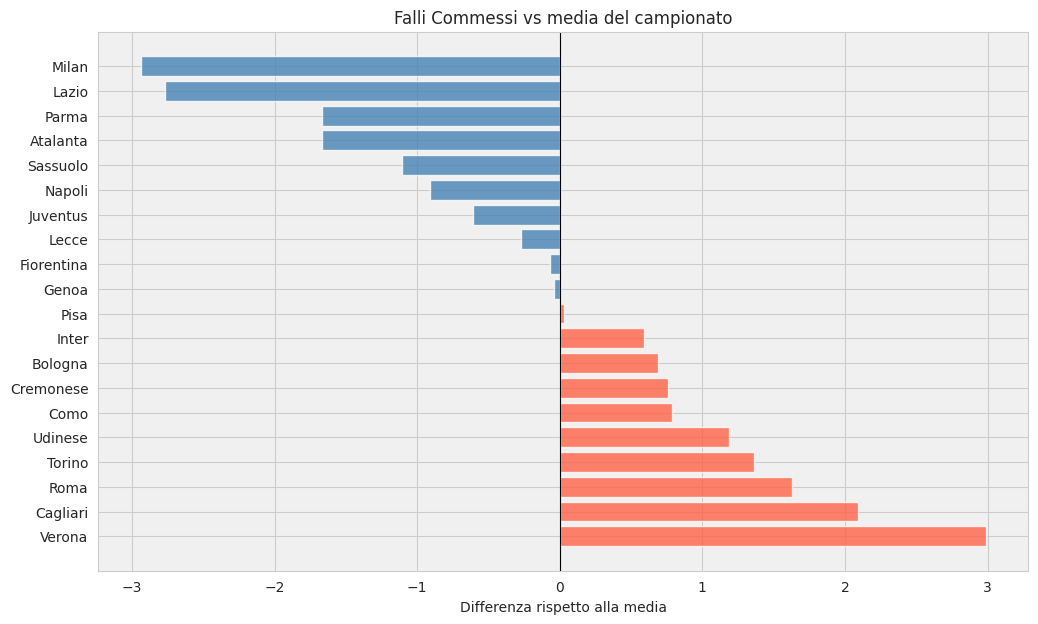

In [22]:
ts_fouls = team_summary(ita_2526, 'fouls_committed')
fig, ax = plot_league_bar(ts_fouls, 
                          title='Falli Commessi vs media del campionato',
                          xlabel = 'Differenza rispetto alla media')

Se Cagliari e Verona da un lato (squadre con piu' falli commessi) e Lazio e Milan dall'altro (squadre alle quali si fischiano meno falli) sembrano avere dei valori particolarmente diversi, la maggior parte delle squadre si discosta dalla media di un valore inferiore a 2 falli per partita (piu' 2 o meno 2, per la precisione). Volendo andare poi nel particolare, l'Inter ha una media di falli commessi di poco superiore alla media quasi nella stessa misura in cui il Napoli commette meno falli (e forse sara' anche per questo che quest'anno il Napoli subisce piu' reti? Ndr). 

Se vogliamo notare altro dalla tabella e dal grafico, c'e' un dato che riguarda la deviazione standard dell'Inter che risulta la piu' alta rispetto alle altre squadre di Serie A. Questo significa che l'Inter e' "meno prevedibile" per quanto riguarda il numero di falli che gli vengono fischiati contro, con partite dove si registrano molti piu' falli commessi rispetto alla media della squadra e altre dove le vengono fischiati molti meno falli (quanto "molto"? In realta' si riferisce al confronto con le altre squadre). Sempre per quanto riguarda la deviazione standard, la Fiorentina e' la squadra piu' prevedibile, dove i giocatori fanno quasi sempre lo stesso numero di falli. 

Ho scritto che Milan e Verona si discostano dalla media e rappresentano i valori estremi, ma questa differenza e' realmente significativa? O puo' essere dovuta al normale spread dei dati? E allora eseguiamo gli stessi test visti in precedenza e verifichiamolo dal punto di vista statistico.

Partiamo dal Verona ed eseguiamo il test di Student

In [23]:
verona_test_results = test_team_vs_rest(ita_2526, 'fouls_committed', 'Verona', n_permutations=1, seed=42)

verona_test_results.show('student_t')

Verona vs Rest -- fouls_committed
--------------------------------------------------
  team                      Verona
  team_mean                 15.9333
  rest_mean                 12.7860
  difference (team-rest)    +3.1474
  team_std                  3.6571
  rest_std                  4.1271
  team_n                    30
  rest_n                    570
--------------------------------------------------
  student_t                 stat=4.0926, p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  0.8072
  rank_biserial             -0.4227


E il test di Student dice che se ipotizziamo che la media dei falli commessi per partita dal Verona sia uguale a quella *del resto del campionato*, il p-value pari a 0.000 (tot cifre significative) ci dice che e' molto ma molto improbabile, e che l'ipotesi alternativa, che le due medie siano diverse, e' decisamente da favorire.

Cosa ci dice il test di Welch che prende in considerazione che le deviazioni standard della media del campionato e del Verona sono differenti?

In [24]:
verona_test_results.show('welch_t')

Verona vs Rest -- fouls_committed
--------------------------------------------------
  team                      Verona
  team_mean                 15.9333
  rest_mean                 12.7860
  difference (team-rest)    +3.1474
  team_std                  3.6571
  rest_std                  4.1271
  team_n                    30
  rest_n                    570
--------------------------------------------------
  welch_t                   stat=4.5633, p=0.0001  (Sig.)
--------------------------------------------------
  cohens_d                  0.8072
  rank_biserial             -0.4227


Anche nel test di Welch, il p-value e' ben al di sotto della soglia di 0.05 (ossia il 5%). Anche se compare un 1 dopo tre zeri, e il p-value del test di Welch sembra essere piu' grande del p-value di Student, siamo ancora sotto soglia e possiamo dire che la statistica ci dice che il Verona commette piu' falli della media del campionato.

Non credo dunque avremo sorprese per quanto riguarda il Milan.

In [25]:
milan_test_results = test_team_vs_rest(ita_2526, 'fouls_committed', 'Milan', n_permutations=1, seed=42)
milan_test_results.show('student_t')
milan_test_results.show('welch_t')

Milan vs Rest -- fouls_committed
--------------------------------------------------
  team                      Milan
  team_mean                 10.0000
  rest_mean                 13.0982
  difference (team-rest)    -3.0982
  team_std                  3.1623
  rest_std                  4.1498
  team_n                    30
  rest_n                    570
--------------------------------------------------
  student_t                 stat=-4.0269, p=0.0001  (Sig.)
--------------------------------------------------
  cohens_d                  -0.8398
  rank_biserial             0.4650
Milan vs Rest -- fouls_committed
--------------------------------------------------
  team                      Milan
  team_mean                 10.0000
  rest_mean                 13.0982
  difference (team-rest)    -3.0982
  team_std                  3.1623
  rest_std                  4.1498
  team_n                    30
  rest_n                    570
--------------------------------------------------

E allora anche il Milan presenta dei p-value praticamente nulli che ci dicono che la differenza rispetto alla media e' statisticamente rilevante.

Diciamolo francamente, abbiamo l'impressione di aver scoperto l'acqua calda, dato che una differenza di 3 falli nelle medie, con una media di campionato pari a 13 falli per partita e' abbastanza netta. 

Eseguiamo allora il test per tutte le squadre del campionato italiano.

In [26]:
all_teams_results = test_all_teams(ita_2526, 
                                   'fouls_committed', 
                                   n_permutations=1)

all_teams_results[['team', 'team_mean', 'team_std','difference (team-rest)', 
                   'student_t_p',
                   'welch_t_p']].rename(columns={'team':'Squadra',
                                                 'team_mean':'Media Squadra',
                                                 'team_std':'Dev. Std. Squadra',
                                                 'difference (team-rest)':'Diff. Media Squadra vs Resto',
                                                 'student_t_p':'p-value Student t-test',
                                                 'welch_t_p':'p-value Welch t-test'})

,Squadra,Media Squadra,Dev. Std. Squadra,Diff. Media Squadra vs Resto,p-value Student t-test,p-value Welch t-test
19,Verona,15.9333,3.6571,3.1474,0.0000,0.0001
4,Cagliari,15.0333,3.3165,2.2000,0.0047,0.0014
3,Roma,14.5667,3.6073,1.7088,0.0282,0.0172
16,Torino,14.3000,4.9630,1.4281,0.0668,0.1316
8,Udinese,14.1333,3.9017,1.2526,0.1079,0.0972
5,Como,13.7333,4.3066,0.8316,0.2862,0.3095
10,Cremonese,13.7000,4.6472,0.7965,0.3070,0.3647
12,Bologna,13.6333,4.1728,0.7263,0.3516,0.3596
9,Inter,13.5333,5.3610,0.6211,0.4258,0.5366
15,Pisa,12.9667,4.0214,0.0246,0.9749,0.9742


La tabella con i valori dei risultati ci dice che Verona, Cagliari e Roma (del Torino scrivo dopo) hanno delle differenze statisticamente significative rispetto alla media come piu' falli rispetto alla media; Parma, Atalanta, Lazio e Milan differenze statisticamente significative rispetto alla media. A questo punto, e' bene precisare che questo non significa che tutte le altre squadre italiane non abbiano differenze rispetto alla media, ma che questa differenza non rappresenta un fattore sistematico ma piuttosto rientra nella fluttuazione statistica. Volendola tradurla in un linguaggio da bar dello sport, il Lecce e' piu' fortunato quando gli si fischia contro un fallo, il Bologna un po' piu' sfortunato. Poi si puo' sempre dire che la fortuna aiuta gli audaci, e che la differenza puo' essere vista come un atteggiamento della squadra che porta gli arbitri a essere lievemente piu' severi, ma che questo atteggiamento sia sistematico, non lo possiamo dire dal punto di vista della statistica.

L'altro punto che mi preme sottolineare (e che fara' scattare un semi momento Barbero), sono i casi limite. Uno di questi e' il caso del Torino.

Secondo la mia scelta di linguaggio puramente scientifico, dalla tabella sembra che il Torino commetta piu' falli rispetto alla media (aggiungendo "e figuriamoci se gli arbitri fischiassero anche i falli che ci sono ma non sono stati sanzionati") e che il test di Student ha calcolato un p-value di 0.06 e il test di Welch 0.13. Entrambi sono sopra la soglia dello 0.05, ma il test di Student appena di un punto percentuale. E' molto? E' poco? Cosa ci dice dal punto di vista statistico? Come ho gia' accennato in precedenza, quando si effettua un test statistico per determinare la differenza tra due misure (le medie di due misure in questo caso), si sceglie a priori una soglia che si ritiene opportuna per determinare la condizione di si/no rispetto al test. Questa soglia, storicamente, viene fissata a 0.05, che significa anche che quando si fanno misure ripetute, si accetta un rate di falsi positivi al massimo del 5%. Se ora vi spaventate perche' ho menzionato i "falsi positivi" avete tutte le ragioni di questo mondo anche perche' questo e' un argomento tecnico che [spesso crea confusione](https://statisticsbyjim.com/hypothesis-testing/p-values-error-rates-false-positives/) ma, detto in maniera molto rozza ma intuitiva, quando all'inizo del test scientifico ho detto che prima di eseguire un test di ipotesi bisogna decidere una soglia $\alpha$, tale soglia rappresenta quante volte siamo disposti ad accettare che il risultato di un test sia sbagliato. Dire che $\alpha$ e' pari a 0.05, o 5%, e trovare un p-value che sia inferiore ad $\alpha$ non significa dire "OK, l'ipotesi nulla e' statisticamente rigettata! Vai con l'alternativa!!" ma piuttosto che se ripetiamo cento volte un esperimento, potremmo trovare fino a 5 casi in cui diciamo che l'ipotesi e' falsa quando invece era vera. Sembra il gioco delle tre carte, ma non lo e' e capirlo, o almeno farsene un'idea, ci aiuta anche a capire ad esempio l'efficacia di un test diagnostico. 
Pensiamo a un test di gravidanza. Nessun test diagnostico e' preciso al 100%, puo' capitare che un test di gravidanza risulti positivo anche se chi lo fa non lo e'. Quando si fa un test diagnostico, infatti si precisa la sensibilita' e la specificita' del test (e non voglio scriverne in questo articolo, ovviamente). $\alpha$ e' uno degli elementi che influenza questi valori e deve essere scelto a priori (ossia prima che si facciano i test in laboratorio e si misurino i risultati). Voglio precisare e sottolineare che $\alpha$ non e' l'unico parametro quando si fanno i test diagnostici, ma che e' un elemento importante da tenere in considerazione. E, anche, il fatto che $\alpha$ puo' cambiare ed essere piu' grande o piu' piccolo dello 0.05 standard, e questo dipende da quanti falsi positivi siamo disposti ad accettare per il nostro test. Dire che il Torino, che presenta un t-test di Student di 0.06, lo rende statisticamente non significativo se scegliamo $\alpha$ pari 0.05, diventa significativo se avessimo scelto un $\alpha$ pari 0.10 (o 10%). Se parliamo di calcio, e vogliamo essere piu' certi di scovare le differenze, allora $\alpha$ pari 0.05 va bene e dormiamo tranquilli. Se invece vogliamo ridurre i falsi positivi, ridurremo il valore di soglia e chiederemo al test di essere piu' severo. Mi piace sottolineare che queste tecniche che sto usando per parlare di calcio, sono le stesse che si usano in vari ambiti. Dal punto di vista statistico, gli elementi matematici sono sempre gli stessi. Le ipotesi cambiano e possiamo fare test di ipotesi in ogni campo. Una sola cosa non deve mancare per fare un test di ipotesi statistico: ***i dati***. Senza dati, senza misure, si puo' dire tutto e il contrario di tutto. Se si hanno i dati, e ***si e' rigorosi***, ci piaccia o meno, la realta' vince sulle nostre convinzioni. Tutti questi test statistici che vengono descritti in questo notebook sono seri e affidabili, e sono molto attento a mettere in chiaro le premesse. Quello che stiamo verificando, per gioco, e' un'affermazione. Un'affermazione che prende in considerazione pochi parametri e fa una conclusione. Io sto verificando se quella affermazione, con i pochi parametri che indica, sia statisticamente verificabile o no. Anche se trovassimo una squadra che ha una media di falli fischiati 20 volte inferiore alla media totale, con i dati che ho usato posso solo dire che lo scostamento dalla media totale e' reale. E statistico. Il perche'? Boh, andiamo a vedere altri dati. Andiamo a controllare se magari hanno perso tutte le partite perche' hanno deciso di non fare nessun fallo per vincere una scommessa su Polymarket. Con i dati a disposizione, non posso dirlo. Ora lo spirito di Barbero se ne torna a casa sua, e andiamo a visualizzare la media dei falli commessi da tutte le squadre italiane stagione in corso 2025/26, che ci ho messo un'ora a fare la funzione in Python che mi plotta i dati e non voglio sprecarla.

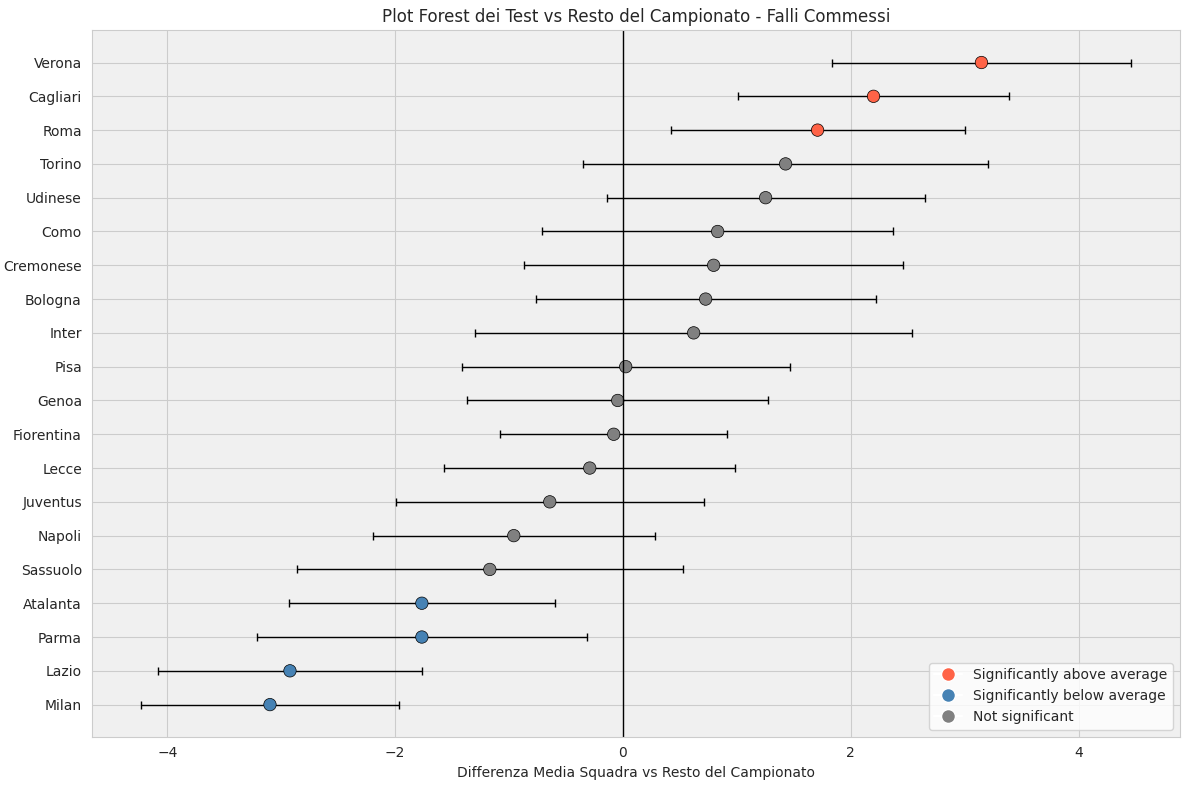

In [27]:
plot_results = all_teams_results.rename(columns={
    'difference (team-rest)': 'diff',
    'welch_t_p': 'welch_p'
})

fig, ax = plot_forest(plot_results, ita_2526, 'fouls_committed',
                      title='Plot Forest dei Test vs Resto del Campionato - Falli Commessi',
                      xlabel='Differenza Media Squadra vs Resto del Campionato')

Se volete far bella figura con i vostri amici, potete dire che questa visualizzazione si chiama Forest Plot. Se poi credete di far bella figura perche' sapete cosa sia un Forest Plot, sono problemi vostri (o dei vostri amici). Il grafico mostra le barre di errore rispetto alla media delle squadre e da anche un suggerimento visivo ai valori che sono significativamente differenti: quelli per i quali le barre di errore non passano per lo 0. L'ho detto? E allora vi dico subito: non fidatevi dei grafici e andate a leggere per bene i p-values. Il grafico e' utile, intuitivo ma sono i numeri che contano. Sempre.  

### Partiamo dalle basi: i cartellini gialli

Dopo aver studiato i falli commessi dalle varie squadre di serie A, possiamo ora analizzare il numero di cartellini gialli comminati. Nei paragrafi precedenti, abbiamo scritto di normalita' dei dati, della loro distribuzione e alcune tecniche per testare alcune ipotesi circa i falli commessi. Proviamo quindi ad applicare quanto discusso in precedenza anche al caso dei cartellini gialli, anche se cartellini gialli e falli commessi sono misure che presentano varie differenze. La prima, banale, e' che se la media dei falli commessi per partita per squadra va dai 10 ai 15 falli, non ci aspettiamo gli stessi numeri per i cartellini. C'e' anche un discorso sull'indipendenza degli eventi che andrebbe affrontato, ma per essere il piu' semplici possibili, i cartellini gialli sono, spesso ma non sempre, conseguenza dei falli commessi. Si possono ammonire i giocatori per proteste, perdite di tempo, per essersi tolti la maglietta dopo aver segnato un goal, ma comunque non sembrano eventi statisticamente indipendenti gli uni dagli altri. Ma il differente numero di eventi registrati e' sicuramente la differenza che pesa di piu' nell'uso degli strumenti statistici che abbiamo discusso in precedenza.

Come fatto per i falli, visualizziamo la distribuzione dei cartellini gialli comminati per partita.

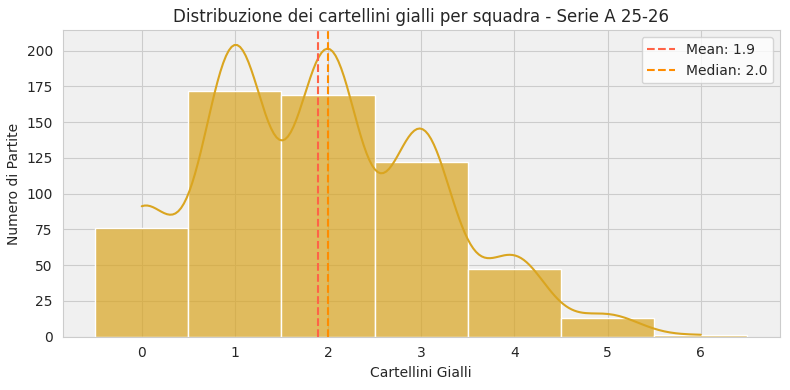

In [28]:
fig, ax = plot_distribution(ita_2526, 
                            'yellow_cards', 
                            title='Distribuzione dei cartellini gialli per squadra - Serie A 25-26',
                            color='goldenrod', 
                            bins=range(0, 10),
                            figsize=(8, 4), 
                            xlabel='Cartellini Gialli',
                            ylabel = 'Numero di Partite',
                            discrete=True)

In [29]:
ita_2526['yellow_cards'].describe()

count    600.000000
mean       1.891667
std        1.233883
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: yellow_cards, dtype: float64

In [30]:
(ita_2526['yellow_cards']
 .value_counts()
 .sort_index()
 .reset_index()
 .rename(columns={'yellow_cards':'cartellini gialli',
                  'count' : 'numero di partite'},
         )
)

,cartellini gialli,numero di partite
0,0.0,76
1,1.0,172
2,2.0,169
3,3.0,122
4,4.0,47
5,5.0,13
6,6.0,1


Se il grafico dei falli commessi era regolare, pressoche' simmetrico rispetto al suo centro, i cartellini gialli hanno un intervallo molto piu' ridotto, da 0 a 6, due picchi per i valori 1 e 2 e a destra, la coda della curva si e' molto poco pronunciata. Questo e' quello che puo' accadere quando gli eventi sono **rari**. Ogni squadra riceve circa due cartellini gialli per gara in media. Un altro paio di considerazioni circa i numeri che escono fuori dal grafico:

- Media e mediana sono ancora molto ravvicinate: anche se la distribuzione non e' simmetrica, non e' pero' terribilmente asimmetrica
- La deviazione standard di circa 1.2 e' molto grande rispetto alla media. Se ho una media di 2 con un errore di 1, qui la variabilita' relativa e' di oltre il 50% (piu' vicino al 60%), mentre nel caso dei falli era circa il 30%
- 76 partite non hanno registrato nessun cartellino giallo per una squadra, ossia circa il 12.5% dei dati. Registrare zero falli, come abbiamo visto in precedenza, era molto anomalo.

Tutto questo per dire che se usiamo le ipotesi fatte per i falli, le conclusioni che possiamo trarre non saranno molto precise. I test che abbiamo usato, infatti, sono particolarmente efficaci se l'insieme dei possibili risultati e' sufficientemente grande e un'approssimazione con funzioni continue rappresenta un modello accettabile. 

E' giunto quindi il momento di introdurre altre tecniche che funzionano meglio in questo tipo di casi (e che vedremo ci daranno risultati piu' affidabili quando poi parleremo della vera misura statistica che ci interessa: il numero di cartellini gialli per falli) e che ci permettono di eseguire test statistici anche quando i dati non sono distribuiti in maniera approssimativamente semplice come nel caso dei falli.

### Normale, ma quanto normale?

Nel paragrafo "Il modello e la realta'", abbiamo accennato a cosa intendiamo per distribuzione normale e di quanto sia vantaggioso avere un modello cosi' semplice quando cerchiamo di trarre una conclusione partendo da dei dati che seguono una distribuzione normale. 

Per quanto riguarda i falli commessi, ad esempio, abbiamo accettato il fatto che, sebbene non perfettamente normale, la distribuzione dei dati lo era abbastanza da poter usare il modello gaussiano senza perdere di affidabilita' o precisione per lo scopo della nostra ricerca. In parole povere, eravamo consci del fatto che usando un modello gaussiano avremmo avuto dei risultati non precisissimi ma abbastanza affidabili per poter aver fiducia che i dati dessero risposte corrette. Ma qual e' il vantaggio di modellare i nostri dati come normali (o gaussiani)? Se qualcuno ci dice che in Serie A le squadre commettono in media 13 falli per gara piu' o meno 4 falli, automaticamente in testa abbiamo un concetto di simmetria: ci saranno circa la meta' delle partite in cui si faranno piu' di 13 falli e l'altra meta' meno di tredici e nella maggior parte dei casi pero' non saranno meno di 9 o piu' di 17 o comunque valori estremi in entrambi i limiti.  

Quel concetto di "piu' o meno", nel caso normale, fa proprio quello che ci immaginiamo: l'errore e' equilibrato attorno alla media, che fare piu' di quattro falli piu' della media e' probabile quanto farne quattro in meno. La variazione e' la stessa in entrambe le direzioni e la media e' posizionata al centro della distribuzione. Ed e' proprio quello come e' fatta la distribuzione normale: quando i dati sono gaussiani, la media e la deviazione standard sono gli unici parametri che descrivono i dati in tutto e per tutto. Dove si trova il centro, e dove si trovano i valori estremi. In generale, si indica con $\sigma$ (sigma) il valore della deviazione standard e chi si occupa di dati o misure, conosce a memoria i valori di uno, due e tre sigma, ossia 68-95-99.7: il 68% dei valori cade in una deviazione standard, il 95% in due deviazioni standard e il 99.7% dei dati all'interno dei tre sigma. Ancora, se volete far bella figura a una festa, potete sempre affermare "la mia convinzione copre i 3 sigma" per dire che i fatti da voi citati capitino il 99.7%. Poi, se c'e' qualcuno che vi vuol bene, chiamano la neuro ma siete stati almeno per cinque minuti l'anima della festa.    

### Un test di normalita'

A questo punto ci possiamo domandare: siamo sicuri che il modello normale ci dara' poi delle risposte affidabili? Quando faro' il confronto tra il numero di cartellini gialli che una squadra riceve rispetto alle altre, questo confronto sara' affidabile? Se utilizzo i test che ho descritto in precedenza nel caso in cui l'ipotesi di normalita' e' ben lontana dall'essere soddisfatta, le conclusioni alle quali arrivero' saranno meno affidabili. Anche troppo. Insomma, [se metto un cervello "non proprio normale" nel corpo di un gorilla alto piu' di due metri e largo come un armadio a due ante](https://www.youtube.com/watch?v=Z7L3PcrhnEg), e' probabile che il risultato possa essere disastroso.  

Ci sono mezzi analitici per capire se una distribuzione e' normale al di la di controllare l'istogramma dei dati, i due approcci principali sono uno visuale e l'altro formale. Quello visuale si chiama Q-Q plot, e visualizza il confronto con i dati reali con quelli di una distribuzione normale; quello formale e' il test di ***Shapiro-Wilk***, che calcola il p-value (eh, si, ancora lui) quando l'ipotesi nulla e' "i dati provengono da una distribuzione normale". Una nota tecnica utile: quando i dati sono pochi (e.g. 300 partite non sono molte), il test di Shapiro-Wilk puo' essere troppo sensibile e rifiutare la normalita' anche su dati che, per i nostri scopi, possiamo considerare normali. Ma forse con un esempio ci chiariamo ancora di piu' le idee, anche se in questa sede non vedremo come si calcola il test. 

Cominciamo con i falli commessi visualizzando il Q-Q plot e calcolando il test Shapiro-Wilk

All    -- W=0.9894, p=0.000245 Not normal (p<0.05)
Home   -- W=0.9887, p=0.019606 Not normal (p<0.05)
Away   -- W=0.9873, p=0.009606 Not normal (p<0.05)


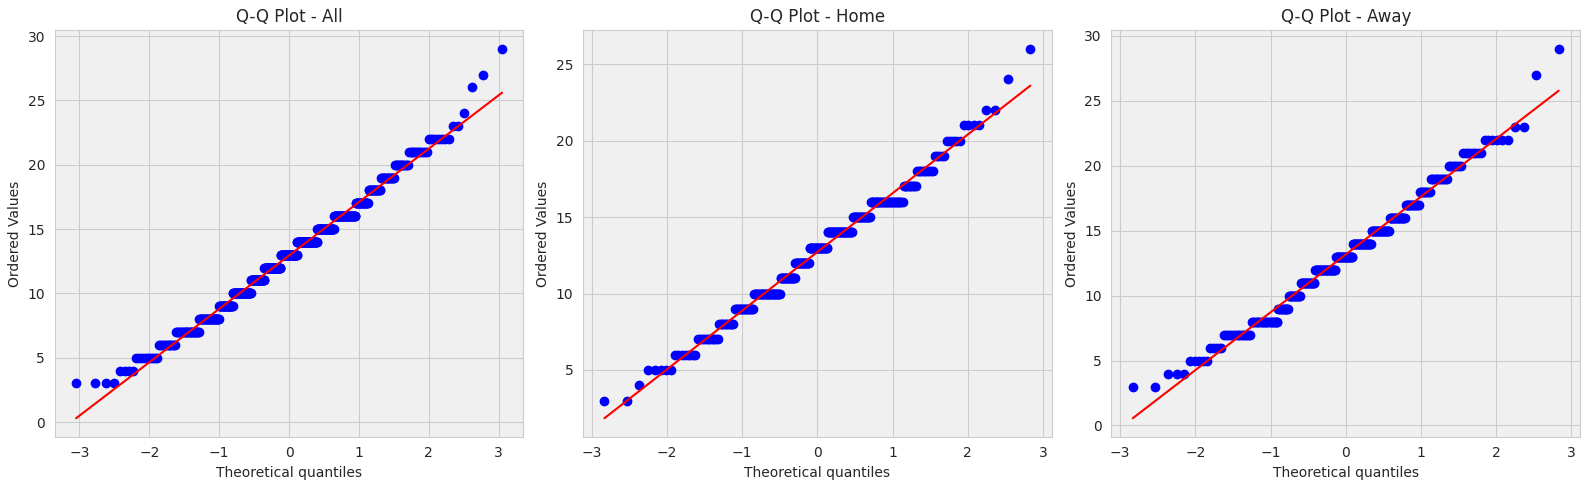

In [31]:
fig, norm_results = check_normality(ita_2526, 'fouls_committed')

Partiamo dal Q-Q plot (ossia il grafico). Se i dati fossero perfettamente normali, i punti blu dovrebbero sovrapporsi alla linea rossa. Come si vede dal grafico, i dati reali (blu) si sovrappongono ai valori teorici nella parte centrale (tra i 5 e poco piu' di 20 falli - asse $y$) ed e' li dove si concentrano la maggior parte dei dati. Agli estremi, abbiamo lo scostamento dal comportamento normale: a sinistra (pochi falli) non scendono al di sotto dei 3 falli, cosa anche logica dato che meno di tre falli e' difficile fischiare in una partita; anche a destra abbiamo uno scostamento dalla linea teorica e i dati indicano che ci sono (rari) casi in cui il numero di falli diventa molto piu' alto del previsto. Come se le partite piu' fallose siano molto piu' fallose del normale.  Il grafico, quindi, ci dice che in condizioni non estreme (pochissimi o moltissimi falli) i dati sono normali. Il p-value del test "I dati sono normali" e' al di sotto della soglia del 5%, e ci dice che quindi non passano il test di normalita' ma, come ho sottolineato in precedenza, quando abbiamo pochi dati, e' quello che ci aspettiamo. I dati dei falli commessi sono in larga parte normali. 

E questo lo notiamo ancora di piu' se andiamo ad analizzare i cartellini gialli subiti.

All    -- W=0.9250, p=0.000000 Not normal (p<0.05)
Home   -- W=0.9181, p=0.000000 Not normal (p<0.05)
Away   -- W=0.9262, p=0.000000 Not normal (p<0.05)


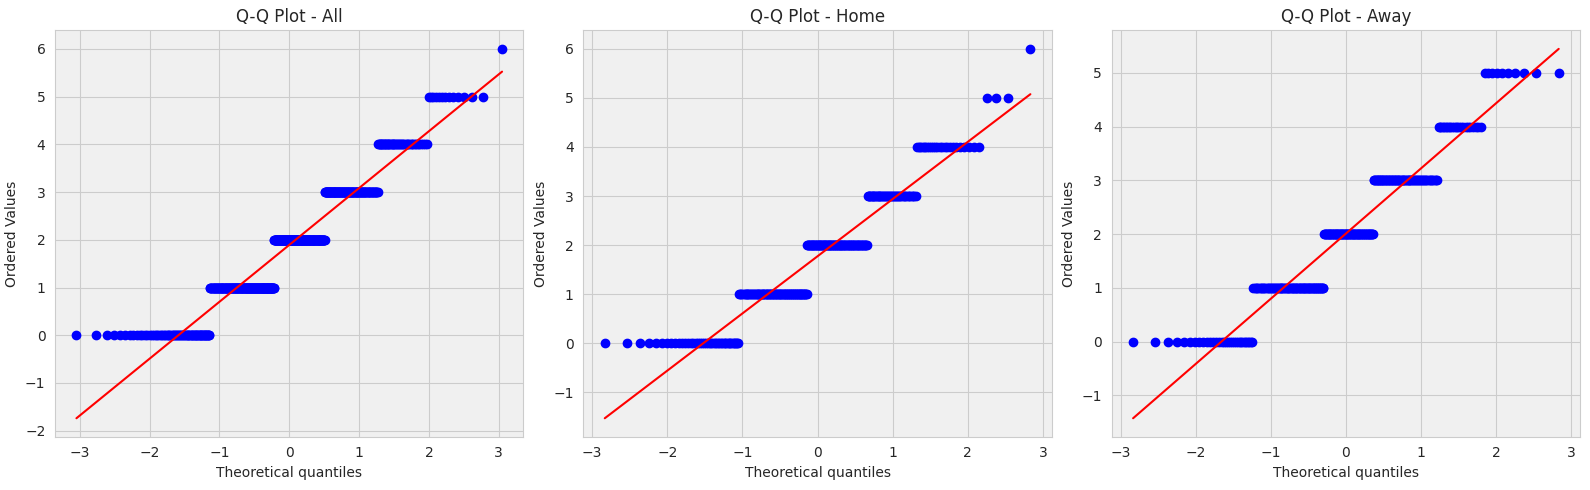

In [32]:
fig, norm_results = check_normality(ita_2526, 'yellow_cards')

Con i falli, i punti blu si sovrapponevano alla linea rossa in maniera molto piu' precisa. Dobbiamo anche sottolineare il fatto che parliamo di quantita' discrete e che quindi piu' partite hanno lo stesso numero di falli. Quando andiamo a vedere cosa succede per i cartellini gialli, i punti formano una vera e propria scaletta con bande orizzontali tra 0 e 6

Confrontiamo il valore delle statistiche di Shapiro-Wilk $W$ e abbiamo $W=0.9894$ per i falli commessi mentre un valore molto piu' basso $W=0.9250$ per i cartellini gialli. No, i cartellini gialli sono decisamente abby-normal. E se nel caso dei falli commessi ci potevamo accontentare e dire "non sono normali ma nella nostra approssimazione possono essere considerati tali", i dati per i cartellini gialli e la nostra bella curva normale appartengono a mondi separati.

E quindi questo cosa significa per i test che abbiamo usato nel caso dei falli? Come possiamo confrontare medie e altri valori con questi dati? Una considerazione utile: i cartellini gialli per partita assumono pochissimi valori discreti diversi (praticamente da 0 a 5), e questo gia' da solo rende il modello gaussiano inadeguato, al di la' del risultato di Shapiro-Wilk. Per fortuna, in un'era dove non c'erano cellulari e i ragazzini andavano all'oratorio a giocare a pallone, c'erano anche statistici e, in generale scienziati, che hanno studiato metodi per trattare dati quando la loro distribuzione non e' gaussiana. 

Andiamo avanti e cerchiamo di introdurre in maniera semplice alcuni concetti che ci danno la possibilita' di condurre dei test statistici con questo tipo di dati.

### Il test $U$ di Mann-Whitney  

Il test $U$ di Mann-Whitney e' un test non parametrico che verifica se due campioni statistici provengono dalla stessa popolazione. Detta cosi', potrebbe essere non chiaro il legame con quello che vogliamo studiare. Se il nostro interrogativo di base e' sapere se il numero di cartellini gialli di una squadra sia coerente, commisurabile, sia lo stesso della "media" delle altre squadre, cosa c'entra verificare se due campioni statistici provengono dalla stessa popolazione? Dal punto di vista formale statistico, e' quello che fa il test di Mann-Whitney: prendiamo il numero dei cartellini gialli di una squadra e ci chiediamo se appartiene alla stessa distribuzione statistica del resto delle altre squadre. Nel farlo, il test di Mann-Whitney non confronta le medie ipotizzando che siano distribuite normalmente, ma si chiede: se prendo casualmente, in maniera random, il numero di cartellini gialli della squadra che voglio confrontare con il resto delle altre , e prendo, sempre in maniera random, il numero di cartellini gialli di un'altra squadra, chi ha preso piu' cartellini gialli? Semplificando ulteriormente, se voglio confrontare il numero di cartellini gialli ricevuti dall'Inter con il resto delle altre squadra, prendo una partita a caso dell'Inter e conto il numero di cartellini gialli che ha ricevuto, chiamiamolo $n_{Inter}$, poi prendo a caso una partita a caso di un'altra squadra $x$ e conto il numero di cartellini gialli che ha ricevuto la squadra $x$, chiamiamolo $n_{x}$. Ovviamente, non faccio questa operazione una sola volta ma considero tutte le possibili coppie di confronti tra una partita dell'Inter e una partita di un'altra squadra, e per ognuna vedo chi ha preso piu' cartellini. Dopo questa operazione, vado a fare quello che si chiama il *ranking* dei risultati: ordino il numero di cartellini gialli dei due gruppi e assegno il posto in classifica ai vari numeri che sono usciti. Piu' il numero di cartellini gialli e' alto, piu' il ranking e' alto (come se facessi una gara a quanti piu' cartellini gialli si fanno). Senza entrare nei dettagli, a questo punto ho un modo per confrontare se il numero di cartellini gialli ricevuti dall'Inter e' sistematicamente piu' grande (o piu' piccolo) rispetto al numero di cartellini gialli ricevuti dalla squadra $x$ presa a caso. Posso quindi concludere, con una certa confidenza, se l'Inter, tendenzialmente, riceve piu' o meno cartellini gialli rispetto al resto delle altre squadre. Il vantaggio del test di Mann-Whitney e' che la distribuzione dei cartellini gialli, in questo caso, e' ininfluente. Non sto utilizzando medie e deviazioni standard (non sto usando parametri, da qui la definizione di test non parametrico), sto andando a confrontare direttamente il numero di cartellini gialli preso dall'Inter rispetto alle altre squadre caso per caso. 

La differenza tra un t-test e un test non parametrico come quello di Mann-Whitney e' che se il t-test risponde alla domanda "ho due medie significativamente diverse dal punto di vista statistico?", il test di Mann-Whitney risponde alla domanda "uno dei due gruppi produce dei valori maggiori rispetto a un altro?". Quando le distribuzioni hanno una forma simile, le domande danno le stesse risposte (e, di fatto, il t-test e il test di Mann-Whitney danno gli stessi risultati). Se le forme sono differenti, il test di Mann-Whitney e' piu' affidabile. 

In [33]:
inter_yc = ita_2526[ita_2526['team'] == 'Inter']['yellow_cards']
rest_yc = ita_2526[ita_2526['team'] != 'Inter']['yellow_cards']
inter_yc.describe()

count    30.000000
mean      1.666667
std       1.028334
min       0.000000
25%       1.000000
50%       1.500000
75%       2.000000
max       4.000000
Name: yellow_cards, dtype: float64

In [34]:
rest_yc.describe()

count    570.000000
mean       1.903509
std        1.243396
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: yellow_cards, dtype: float64

In [35]:
# Student's t-test
t_stat_s, t_p_s = stats.ttest_ind(inter_yc, rest_yc, equal_var=True)

# Welch's t-test
t_stat_w, t_p_w = stats.ttest_ind(inter_yc, rest_yc, equal_var=False)

# Mann-Whitney U
u_stat, u_p = stats.mannwhitneyu(inter_yc, rest_yc, alternative='two-sided')
n1, n2 = len(inter_yc), len(rest_yc)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

observed_diff = inter_yc.mean() - rest_yc.mean()

print(f"Differenza osservata (Inter - Altre squadre): {observed_diff:.4f}")
print(f"t-test di Student:    t={t_stat_s:.4f}, p={t_p_s:.4f}")
print(f"t-test di Welch :      t={t_stat_w:.4f}, p={t_p_w:.4f}")
print(f"U test di Mann-Whitney:      U={u_stat:.1f}, p={u_p:.4f}")
print(f"Rank-biserial:       {rank_biserial:.4f}")

Differenza osservata (Inter - Altre squadre): -0.2368
t-test di Student:    t=-1.0248, p=0.3059
t-test di Welch :      t=-1.2156, p=0.2326
U test di Mann-Whitney:      U=7698.5, p=0.3437
Rank-biserial:       0.0996


Cosa ci dice la tabella che ci siamo ricavati:
1. La differenza in media tra il numero di cartellini gialli tra l'Inter e il resto delle altre squadre e' di circa -0.24, ossia all'Inter vengono dati in media, per partita, circa -0.24 cartellini gialli rispetto alle altre (non tantissimo)
2. Il t-test di Student (quello che ipotizzava una distribuzione normale in cui la dispersione dei dati rispetto alle due medie sia uguale) mi dice che la differenza non e' significativa, con un p-value di circa 0.31
3. Anche il t-test di Welch (quello che ipotizzava una distribuzione normale in cui la dispersione dei dati delle due medie NON era uguale) mi dice che la differenza non e' significativa con un p-value di 0.23
4. Il test di Mann-Whitney (quello che non fa alcuna ipotesi circa la distribuzione dei dati e la loro dispersione) ci dice che la differenza non e' significativa e il p-value e' di 0.34
5. Il Rank-biseriale e' una misura dell'effetto della differenza (quanto sarebbe evidente o forte la differenza). Se la differenza fosse significativa, un rank biseriale di 0.1 sarebbe veramente piccolo. Insomma, se anche questa differenza ci fosse, l'effetto sarebbe molto piccolo. 

In questo caso tutti e tre i test concordano: non c'e' differenza tra il numero di cartellini gialli che riceve l'Inter e il resto delle squadre di Serie A per la stagione in corso. A che e' servito introdurre il test di Mann-Whitney se ci ha dato la stessa risposta dei due t-test? Se confrontiamo i p-value dei tre test, vediamo che il valore piu' alto e' proprio quello di Mann-Whitney. Un p-value piu' alto ci dice che i dati sono ancora piu' compatibili con l'ipotesi che non ci sia differenza(e ripetiamo per l'ennesima volta che quando la differenza non e' statisticamente significativa, significa che la differenza che misuriamo e' dovuta sostanzialmente a una fluttuazione statistica e non e' sistematica). Il fatto che test di Mann-Whitney, quello piu' affidabile nel caso del tipo di distribuzione dei cartellini gialli, abbia il p-value maggiore, ci suggerisce che le medie sono sostanzialmente uguali con un maggior grado di affidabilita'. Insomma, non ci sono santi: dal punto di vista statistico l'Inter riceve lo stesso numero di cartellini gialli di tutte le altre squadre di Serie A.  

Ora che abbiamo un nuovo strumento nel nostro repertorio (il test di Mann-Whitney), andiamo a vedere piu' nel dettaglio come vengono comminati i cartellini gialli nel campionato di Serie A in corso.

In [36]:
all_results = test_all_teams(ita_2526, 
                             'yellow_cards', 
                             n_permutations=1) 

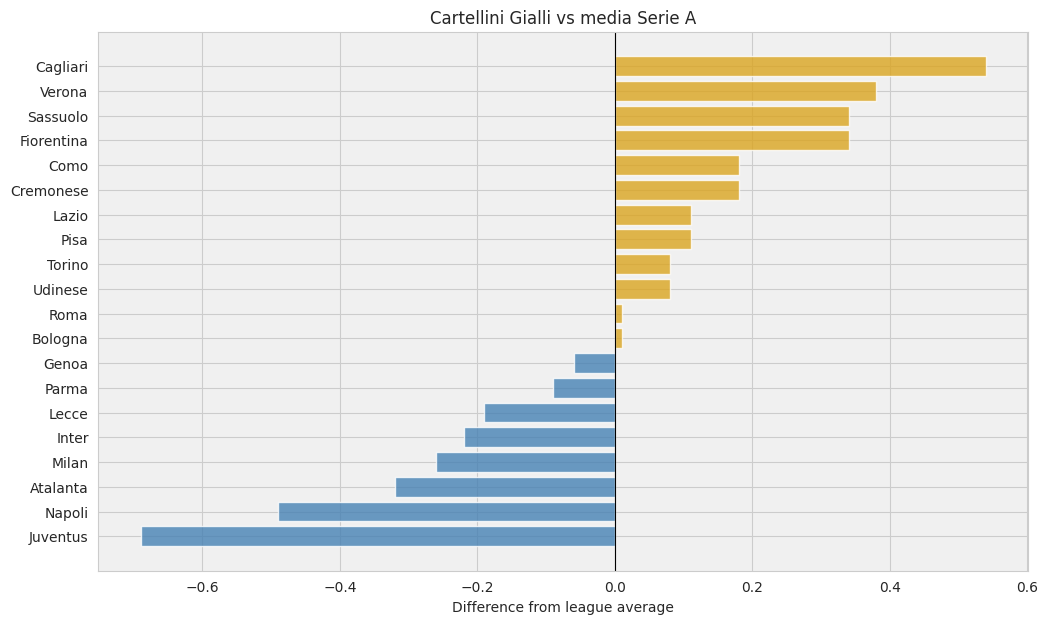

In [37]:
ts_ycards = team_summary(ita_2526, 'yellow_cards')
fig_yc, ax_yc = plot_league_bar(ts_ycards.sort_values('diff_from_league', ascending=True), 
                                title='Cartellini Gialli vs media Serie A',
                                above_color='goldenrod', 
                                below_color='steelblue')

In [38]:
cols = ['team', 'team_mean', 'rest_mean', 'difference (team-rest)', 
       'student_t_p', 'welch_t_p','mannwhitney_p', 
       'rank_biserial']
all_results[cols].rename(
    columns={
        'team':'squadra',
        'team_mean': 'media',
        'rest_mean': 'media altri',
        'difference (team-rest)' : 'differenza tra medie',
        'student_t_p' :'p-value student',
        'welch_t_p' : 'p-value welch',
        'mannwhitney_p' : 'p-value MW',
    }
).reset_index(drop = True)

,squadra,media,media altri,differenza tra medie,p-value student,p-value welch,p-value MW,rank_biserial
0,Cagliari,2.4333,1.8632,0.5702,0.0135,0.0558,0.0265,-0.2332
1,Verona,2.2667,1.8719,0.3947,0.0877,0.1032,0.0737,-0.1881
2,Sassuolo,2.2333,1.8737,0.3596,0.1198,0.1263,0.1131,-0.1666
3,Fiorentina,2.2333,1.8737,0.3596,0.1198,0.1263,0.0902,-0.1782
4,Cremonese,2.0667,1.8825,0.1842,0.4259,0.3731,0.3776,-0.0928
5,Como,2.0667,1.8825,0.1842,0.4259,0.4299,0.3068,-0.1075
6,Lazio,2.0000,1.8860,0.1140,0.6221,0.6729,0.7989,-0.0268
7,Pisa,2.0000,1.8860,0.1140,0.6221,0.6169,0.5629,-0.0609
8,Torino,1.9667,1.8877,0.0789,0.7330,0.7257,0.6716,-0.0446
9,Udinese,1.9667,1.8877,0.0789,0.7330,0.7518,0.8635,-0.0181


A differenza dei falli commessi, dove avevamo sette squadre la cui differenza dalla media era statisticamente significativa, nel caso dei cartellini gialli ne abbiamo di meno e con p-value meno marcati.

Ci sono due squadre per le quali tutti i test (Student, Welch e Mann-Whitney) sono statisticamente significativi (il valor medio dei cartellini gialli della squadra ben al di sotto della media per partita delle altre squadre): una e' la Juventus che e' di gran lunga la squadra a cui vengono dati un numero di cartellini gialli per partita ben al di sotto della media del campionato (i tre test hanno tutti valori al di sotto del 5%). L'altra squadra e' il Napoli, il cui comportamento dei suoi difensori si dimostra esemplare e rispettoso delle regole, con una media per partita inferiore alla media per partita del resto delle squadre del campionato (anche qui i tre test concordano).

Sopra la media, invece, c'e' il Cagliari, con un valore di 2.4 cartellini gialli contro una media di 1.8 per le squadre rimanenti. A questo punto e' anche bene ribadire che il confronto delle singole squadre e' fatto rispetto al resto delle altre squadre, il che significa che quando si fa la media delle squadre, non si tiene conto del numero dei cartellini della squadra con la quale si fa il confronto, ed e' per questo che la colonna `media altri` e' diversa da squadra a squadra: quando si calcola la `media altri`, non si considerano i cartellini gialli assegnati alla squadra che si confronta. Per il Cagliari, e' interessante notare che il p-value del test di Welch e' di poco al di sopra del 5%. E' uno di quei casi limite in cui la scelta del test e della soglia risulta decisiva. Se usassimo un modello normale a varianza diversa con soglia al 5%, potremmo dire che la differenza tra media Cagliari e media altre squadre non e' significativa. Se invece consideriamo un test piu' affidabile come quello di Mann-Whitney, con la stessa soglia, la differenza diventa significativa dato che il p-value e' di 0.02. Siamo comunque al limite. E l'Inter? L'Inter, come abbiamo detto in precedenza, ha un valore medio di poco inferiore alla media del campionato ma non significativo e quindi rientra in un comportamento nella media. 

Prima di proseguire, riassumiamo graficamente la differenza tra media campionato e delle singole squadre per falli e cartellini gialli separatamente e vediamo se notiamo qualcosa di interessante.

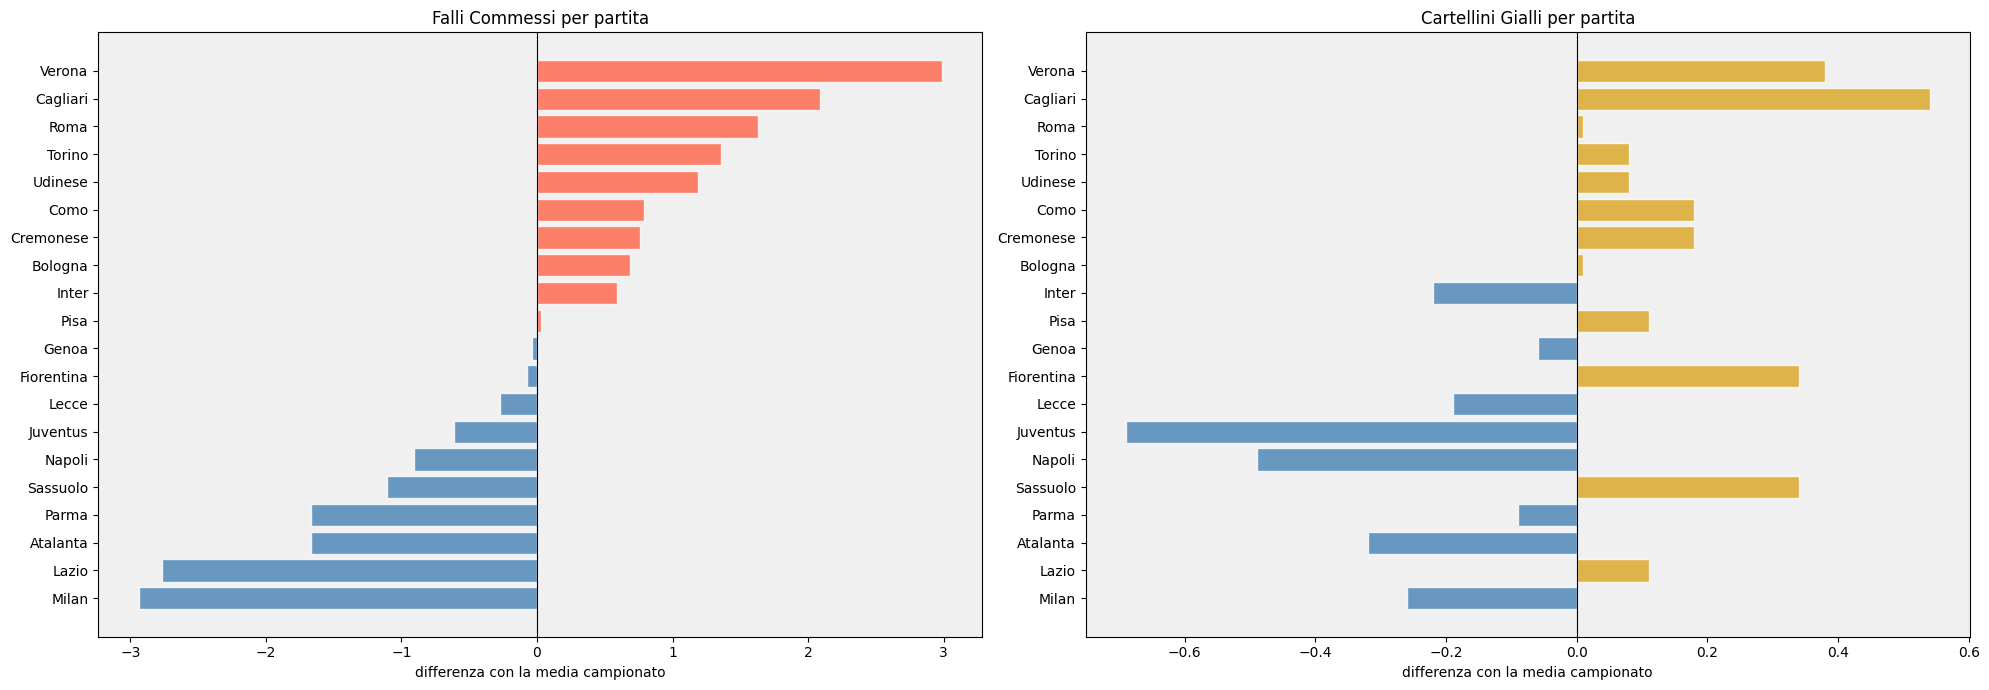

In [39]:
# Get team order from fouls (sorted by diff_from_league)
fouls_sorted = ts_fouls.sort_values('diff_from_league')
team_order = fouls_sorted.index

# Reindex yellow cards to match
yc_sorted = ts_ycards.loc[team_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

plot_league_bar(fouls_sorted, 
                title='Falli Commessi per partita', 
                xlabel='differenza con la media campionato',
                ax=ax1)
plot_league_bar(yc_sorted, title='Cartellini Gialli per partita',
                above_color='goldenrod', xlabel='differenza con la media campionato', ax=ax2)

fig.tight_layout()

E qui qualcosa di interessante c'e'. Verona e Cagliari fanno piu' falli a partita rispetto alla media e ricevono piu' cartellini gialli. Dall'altra parte dello spettro, al Milan vengono fischiati meno falli per partita della media, e riceve meno cartellini gialli. Alla Juventus vengono fischiati meno falli e riceve in media meno cartellini gialli. Sembra logico. 

Piu' interessante e' quando i casi sembrano non concordare, come la Fiorentina che fa leggermente meno falli, rispetto alla media, e riceve leggermente piu' ammonizioni, sempre rispetto alla media. Attenzione, stiamo comunque parlando di valori che non sono statisticamente diversi in maniera significativa se considerati singolarmente, ma se ne consideriamo il rapporto?

Ad esempio, l'Inter. Ha una media di falli commessi di poco superiore alla media, e una media di cartellini gialli inferiore alla media. Come visto, non significativamente diversi dal punto di vista statistico singolarmente. Ma noi vogliamo studiare il rapporto, ossia quanti cartellini gialli vengono comminati per falli commessi. Insomma, se il valore della media dei falli per partita non e' statisticamente differente dalla media cosi' come non lo e' il valore dei cartellini gialli per partita, ma mentre uno e' sotto la media (di poco) e l'altro e' sopra la media (di poco), puo' il rapporto diventare invece statisticamente diverso in maniera significativa?

E' quello che andremo a studiare nel prossimo, decisivo, paragrafo.

## Cartellini gialli per falli commessi - The Endgame

Nella parte finale del paragrafo precedente abbiamo visto come ci sono squadre che sembra non ricevano un numero di cartellini gialli proporzionale al numero di falli commessi. Ed e' proprio questo il punto sollevato dal professor Siciliano quando parla di Inter come dato anomalo per numero di cartellini per falli commessi. Dopo aver studiato separatamente i falli commessi e i cartellini ricevuti, siamo finalmente pronti per analizzare il loro rapporto. Ed e' proprio questa una metrica cruciale che normalizza lo stile di gioco: ci dice non quanto una squadra sia fallosa, ma quanto spesso i falli risultino in un'ammonizione. 

### Definiamo la metrica

Il rapporto tra ammonizioni comminate e falli commessi isola la domanda che ci siamo posti, ossia: dato un fallo commesso, qual e' la probabilita' che poi scatti un'ammonizione (non so perche', ma le ammonizioni "scattano")? 

$$\text{cartellini\_per\_falli}_{i} = \frac{\text{cartellini\_gialli}_{i}}{\text{falli\_commessi}_{i}}$$

Dove l'indice $i$ si riferisce a ogni partita.

Una scelta motivata: perche' calcolare cartellini per fallo e non falli per cartellino? L'informazione e' la stessa (una e' l'inverso dell'altra), ma per convenzione la "variabile di esposizione" — quella che, in principio, causa l'altro evento — si colloca a denominatore. Qui il cartellino e' conseguenza del fallo, salvo le eccezioni gia' discusse in precedenza. C'e' anche una ragione pratica: partite senza falli sono rare, partite senza ammonizioni lo sono molto meno, e si evita cosi' di dividere per zero.

### I due modi per misurare il rapporto

Abbiamo definito il rapporto per partita, adesso dobbiamo riassumerlo per quanto riguarda le singole squadre. Abbiamo due modi per farlo e i due approcci danno una risposta leggermente differente.

1. Media dei rapporti per singola partita

Calcoliamo il rapporto per ogni partita, poi calcoliamo la media di tutte le partite giocate dalla squadra:

$$\bar{r} = \frac{1}{n} \sum_{i=1}^{n} \frac{\text{cartellini\_gialli}_i}{\text{falli\_commessi}_i}$$

2. Rapporto dei totali per stagione

Calcoliamo la somma dei cartellini gialli e dei falli per tutte le partite e poi dividiamo:

$$R = \frac{\displaystyle\sum_{i=1}^{n} \text{cartellini\_gialli}_i}{\displaystyle\sum_{i=1}^{n} \text{falli\_commessi}_i}$$

Senza entrare nei dettagli, si puo' vedere che il rapporto dei totali ($R$) e' equivalente, dal punto di vista matematico, alla media pesata del rapporto per partita, dove ogni partita e' pesata in base al proprio numero di falli; mentre la media $\bar{r}$ fa si che ogni partita abbia lo stesso peso se consideriamo la stagione intera. Cio' significa che se consideriamo la media $\bar{r}$ (caso 1.), una partita con due falli abbia lo stesso peso di una partita con 20 falli. Il rapporto dei totali $R$ considera ogni singolo fallo in maniera uguale e quindi una partita con 20 falli ha un'influenza 10 volte superiore a una partita con 2 falli.  

Per il tipo di analisi che stiamo conducendo, il rapporto dei totali $R$ e' la scelta piu' opportuna. La domanda alla quale stiamo rispondendo e' "lungo tutta la stagione, per ogni fallo commesso da una squadra, quante volte viene estratto un cartellino giallo?". Cio' che conta e' il fallo, non la partita (chi avesse voglia di approfondire questo passaggio, c'e' un notebook che approfondisce l'analisi del rapporto tra falli commessi e cartellini gialli che lo spiega in maniera piu' analitica). 

Se calcoliamo queste quantita', forse chiariamo meglio i concetti.

In [40]:
rate_table = rate_summary(ita_2526)
(rate_table[['team', 
            'total_denominator', 
            'total_numerator',
            'ratio_of_totals','inv_ratio_of_totals', 
            'mean_ratio', 'inv_mean_ratio',
            ]]
 .rename(columns = {
     'team':'Squadra',
     'total_denominator':'Totale Falli',
     'total_numerator':'Totale Cartellini',
     'mean_ratio': 'y/f media per partita',
     'ratio_of_totals' : 'y/f media totali',
     'inv_mean_ratio' : 'f/y media per partita',
     'inv_ratio_of_totals' : 'f/y media totali'})
)


,Squadra,Totale Falli,Totale Cartellini,y/f media totali,f/y media totali,y/f media per partita,f/y media per partita
0,Juventus,370.0,36.0,0.097297,10.277778,0.097012,10.307972
1,Napoli,361.0,42.0,0.116343,8.595238,0.119034,8.400991
2,Inter,406.0,50.0,0.123153,8.120000,0.130098,7.686495
3,Roma,437.0,57.0,0.130435,7.666667,0.129059,7.748414
4,Lecce,380.0,51.0,0.134211,7.450980,0.142221,7.031294
5,Torino,429.0,59.0,0.137529,7.271186,0.139115,7.188296
6,Atalanta,338.0,47.0,0.139053,7.191489,0.152437,6.560102
7,Udinese,424.0,59.0,0.139151,7.186441,0.153804,6.501771
8,Bologna,409.0,57.0,0.139364,7.175439,0.164417,6.082098
9,Genoa,387.0,55.0,0.142119,7.036364,0.139173,7.185282


Leggiamo questa tabella (che avremmo potuto benissimo calcolarci all'inizio di questo articolo e risparmiarci discussioni su normalita' dei dati, test statistici e altre amenita' varie. Ma poi dove sarebbe stato il divertimento) e cerchiamo di capire le grandezze in gioco. La colonna `y/f media totali` calcola il rapporto cartellini gialli vs falli commessi come rapporto tra le somme totali, mentre `y/f media per partita` calcola la media dei rapporti cartellini vs falli presi per singola partita. Accanto a ogni colonna, c'e' il corrispettivo numero di falli per singolo cartellino.

Consideriamo proprio il caso dell'Inter. La squadra nerazzurra ha commesso 406 falli in totale e ha ricevuto 50 cartellini gialli nelle prime trenta partite del campionato 2025-26. Il rapporto tra Totale Cartellini e Totale falli e' di circa 0.12 il che significa che, per ogni fallo commesso, una frazione di 0.12 cartellini gialli viene comminata. Con l'inverso, forse, si intuisce meglio: l'Inter riceve un cartellino giallo per ogni 8 falli commessi circa. Si nota subito che queste quantita' non cambiano di molto se ci calcoliamo la media considerando il valore per partita (0.13 cartellini gialli per fallo o 7.7 falli per cartellino giallo). Dalla tabella mi sembra evidente che, anche se l'Inter fa piu' falli rispetto alla maggior parte delle altre squadre di Serie A, prima di ricevere un cartellino giallo, il dato non sembra cosi' anomalo come evidenziato dall'affermazione di partenza. Se l'affermazione risulta (quasi) corretta per quanto riguarda il valore dell'Inter (*"l'Inter prende un cartellino giallo ogni otto falli e mezzo"*), la questione della media (*"il valore medio e' un cartellino ogni quattro falli"*) non e' molto precisa.

Detto questo, siamo ancora curiosi di sapere se il dato dell'Inter rappresenta comunque una differenza statistica rispetto alla media delle altre squadre. E per farlo in maniera accurata, dobbiamo ora fare un ultimo, [piccolo sforzo](https://www.youtube.com/watch?v=eNDqEzVy_3s) e introdurre un nuovo strumento statistico dopo il test di Student, di Welch e quello di Mann-Whitney: il ***bootstrapping***. 

### Il test di Ipotesi per un rapporto: perche' abbiamo bisogno di un nuovo strumento

Quando abbiamo preso in considerazione singolarmente falli commessi e cartellini gialli, abbiamo confrontato dei valori medi, nel caso pero' del rapporto tra numero di cartellini gialli e falli commessi, stiamo trattando delle **proporzioni** e non delle medie. Quello che ci stiamo chiedendo in questo caso e' **dato che una certa squadra ha commesso un certo numero di falli, la proporzione di falli che ha poi portato a un'ammonizione e' inusuale rispetto alle altre squadre?**. Quando si parla di test statistici per le proporzioni, l'idea di base del test non cambia: formuliamo l'ipotesi nulla (ossia che non c'e' nessun comportamento inusuale), calcoliamo quanto i dati reali siano improbabili (o probabili) se l'ipotesi e' vera, e calcoliamo il p-value. Alla fine, e' sempre il p-value che andremo a confrontare, come calcolarlo, in questo caso, cambia. Ci sono vari strumenti che ci permettono di farlo, ad esempio lo z-test per le proporzioni, oppure il test binomiale esatto (questi due fanno ipotesi sulla distribuzione dei dati). Prima di arrivare a z-test e binomiale esatto, mi concedo una digressione sul **bootstrap**: e' il metodo che personalmente trovo piu' elegante e piu' facile da raccontare senza formule. E' anche un'ottima palestra per capire cosa stanno facendo, sotto il cofano, anche gli altri test.

### Il bootstrap: un'alternativa indipendente dalla distribuzione

Per spiegare a grandi linee il bootstrap, facciamo un esempio pratico e consideriamo il caso della Juventus (prendo l'estremo per chiarire meglio la procedura). 

In [41]:
team_name = 'Juventus'

team_df  = ita_2526[ita_2526['team'] == team_name]
rest_df  = ita_2526[ita_2526['team'] != team_name]

n  = int(team_df['fouls_committed'].sum())   # number of trials
k  = int(team_df['yellow_cards'].sum())      # number of successes
p_hat = k / n                                # observed rate

p0 = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()  # reference rate

print(f"Squadra                      : {team_name}")
print(f"Falli Commessi (n)           : {n}")
print(f"Cartellini Gialli (k)        : {k}")
print(f"Rate osservato  p̂            : {p_hat:.4f}")
print(f"Rate di riferimento p₀       : {p0:.4f}")
print(f"Differenza  p̂ - p₀           : {p_hat - p0:+.4f}")

Squadra                      : Juventus
Falli Commessi (n)           : 370
Cartellini Gialli (k)        : 36
Rate osservato  p̂            : 0.0973
Rate di riferimento p₀       : 0.1486
Differenza  p̂ - p₀           : -0.0513


Quindi, la Juventus ha commesso 370 falli e ha ricevuto 36 cartellini gialli. Il rate osservato e' di circa 0.1, quello di riferimento, ossia il resto delle altre squadre, e' di circa 0.15, per una differenza, in valore assoluto, di 0.05. 

In un test di ipotesi, come quello binomiale, ci chiediamo se $p_{0}$ e' la probabilita' di ricevere un cartellino giallo per fallo commesso (e $p_{0}$ e' calcolato come la media di tutte le squadre - a rigor di logica, se faccio un certo numero di falli mi aspetto un certo numero di cartellini gialli indipendentemente da quali squadre commettono i falli), quanto e' probabile osservare la probabilita' $\hat{p}$ della Juventus? Il test binomiale esatto usa la distribuzione binomiale, mentre lo z-test usa l'approssimazione normale (che non vale sempre).

Il bootstrap ribalta l'approccio: invece di usare una formula, prende i dati reali di tutte le squadre, li rimescola tante volte come un mazzo di carte, e vede quali valori escono fuori. Se la Juventus fosse una squadra come le altre, il suo valore dovrebbe rientrare tra quelli che escono dal rimescolamento. 

La logica e' semplice anche se, forse, non del tutto intuitiva. Supponiamo di avere le 30 partite della Juventus e le altre 570 partite delle rimanenti 19 squadre. Se il valore della Juventus per quanto riguarda il rapporto tra cartellini gialli e falli, non avesse nulla di speciale allora le loro 30 partite non sarebbero altro che una possibile estrazione casuale tra tutte le partite del campionato. A questo punto, ci chiediamo quale sarebbe il valore del rapporto tra cartellini gialli e falli se scegliamo a caso 30 partite tra tutte quelle giocate nel campionato? Facciamo questa simulazione migliaia di volte e ci andiamo a calcolare la distribuzione che ne viene fuori: questa e' la nostra distribuzione nulla. Ancora piu' semplicemente, andiamo a simulare migliaia di possibili risultati per ogni partita del numero di cartellini gialli per fallo e diciamo "questo e' il comportamento generale". Confrontiamo, infine, il valore del rapporto che invece abbiamo misurato per la Juventus con quello della distribuzione che abbiamo generato e vediamo se quello empirico, quello della Juventus, e' al centro della distribuzione o alla coda: se e' al centro, allora il valore della Juventus e' uno dei tipici risultati ottenuti con la simulazione, altrimenti il dato della Juventus appare diverso dalla norma.     

La cosa importante del metodo del bootstrap, e' che non fa nessuna ipotesi circa la distribuzione dei dati: chiede ai dati stessi una domanda diretta e fa rispondere ai dati, senza invocare nessuna formula matematica. Un inciso semiserio che, qui, ci terrei a sottolineare. Uno si potrebbe chiedere allora perche' usiamo metodi che assumono ipotesi quando ci sono metodi come il bootstrap che simulano e possono dare anche risultati piu' affidabili? Negli studi statistici, o comunque in generale nelle scienze, e' sempre meglio quando si puo' utilizzare un metodo semplice per due motivi principali. Un modello semplice, quale quello normale, e' piu' facile da interpretare e quindi si capisce anche dove intervenire per migliorarlo, mentre altri che agiscono piu' di forza bruta danno un risultato ma e' piu' difficile capirne il perche'. L'altro, e' di semplicita' di calcolo: i metodi come il bootstrap, dovendo fare parecchie migliaia di simulazioni, impiegano molte piu' risorse e, spesso, questo e' un fattore cruciale. 

Riassumiamo la procedura di bootstrap **passo per passo**:

1. **Calcoliamo il valore osservato**: Il valore del rapporto del numero di cartellini gialli per fallo per la Juventus (detto anche *crude rate*) $\hat{p} = k/n$ per la stagione in corso.

2. **Costruiamo la distribuzione nulla**: Prendiamo tutte le partite delle altre 19 squadre (570 partite). Queste rappresentano la squadra "tipo" della Serie A.

3. **Ricampioniamo**: estraiamo 30 partite a caso dalla popolazione nulla (*con rimpiazzamento*, ossia ogni partita puo' essere estratta piu' volte nello stesso campione). Calcoliamo il crude rate per questo campionamento. Questo ci da una stagione simulata per una squadra "tipo" ipotetica.

4. **Ripetiamo**: Rifacciamo il passo 3 molte volte (in questo notebook e' stato fatto 15,000 volte). Ogni ripetizione produce un crude rate. Tutti questi crude rate, assieme, formano la **distribuzione nulla** ossia la distribuzione dei rapporti per la stagione che uno si aspetterebbe da una squadra estratta a caso in Serie A.

5. **Calcoliamo il p-value**: Contiamo quanto spesso la distribuzione nulla produce un risultato estremo almeno quanto quello calcolato per la Juventus. Questa frazione e' il p-value del bootstrap. Dato che eseguiamo il test in entrambe le direzioni (si chiama *two-tailed* test), misuriamo la distanza dalla media dell'ipotesi nulla in maniera simmetrica:

$$p = \frac{1}{B} \sum_{b=1}^{B} \mathbf{1}\!\left[\,\left|\hat{p}_b^* - \bar{p}^*\right| \geq \left|\hat{p} - \bar{p}^*\right|\right]$$

Dove:
- $B = 15{,}000$, $\hat{p}_b^*$ e' il *crude rate* del $b$-esimo campione del bootstrap
- $\bar{p}^*$ e' la media della distribuzione nulla.

OK, quest'ultima formula l'ho lasciata per dare una parvenza di scientificita' all'articolo e anche per dimostrare quanto sono bravo a usare [Latex](https://en.wikipedia.org/wiki/LaTeX), ma fidatevi che funziona.

Media della distribuzione nulla   : 0.1486
Valore Osservato Juventus         : 0.0973
Bootstrap p-value (2-tail): 0.0027


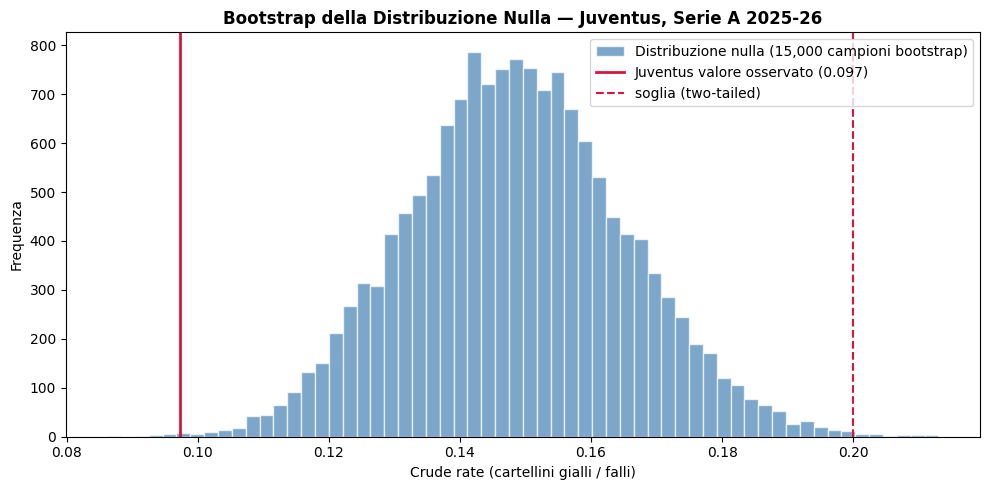

In [42]:
rng = np.random.default_rng(42)
N_BOOTSTRAP = 15_000
m = 30 # numero di partite giocate


null_rates = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    sample = rest_df.sample(n=m, replace=True, random_state=rng.integers(1e9))
    null_rates[i] = sample['yellow_cards'].sum() / sample['fouls_committed'].sum()

null_mean = null_rates.mean()
distance  = abs(p_hat - null_mean)
p_boot    = (np.abs(null_rates - null_mean) >= distance).mean()

print(f"Media della distribuzione nulla   : {null_mean:.4f}")
print(f"Valore Osservato Juventus         : {p_hat:.4f}")
print(f"Bootstrap p-value (2-tail): {p_boot:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_rates, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        label='Distribuzione nulla (15,000 campioni bootstrap)')
ax.axvline(p_hat, color='crimson', linewidth=2,
           label=f'{team_name} valore osservato ({p_hat:.3f})')
ax.axvline(null_mean + distance, color='crimson', linewidth=1.5, linestyle='--',
           label='soglia (two-tailed)')
ax.set_xlabel('Crude rate (cartellini gialli / falli)')
ax.set_ylabel('Frequenza')
ax.set_title(f'Bootstrap della Distribuzione Nulla — {team_name}, Serie A 2025-26',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Il valore osservato del *crude rate* della Juventus (linea rossa continua) e' all'estremo della coda sinistra della distribuzione, il che significa che quando si fanno 15000 simulazioni di questo valore per tutte le squadre, quasi nessuna raggiunge quel valore.  

E l'Inter quindi? Andiamo a vedere qual e' il suo *crude rate*:

In [43]:
inter_stats = compute_team_stats('Inter', ita_2526)
print(f"Squadra                      : {inter_stats['team']}")
print(f"Falli Commessi (n)           : {inter_stats['n']}")
print(f"Cartellini Gialli (k)        : {inter_stats['k']}")
print(f"Rate osservato  p̂            : {inter_stats['p_hat']:.4f}")
print(f"Rate inverso  1/p̂            : {1/inter_stats['p_hat']:.4f}")
print(f"Rate di riferimento p₀       : {inter_stats['p0']:.4f}")
print(f"Rate inverso 1/p₀            : {1/inter_stats['p0']:.4f}")
print(f"Differenza  p̂ - p₀           : {inter_stats['p_hat'] - inter_stats['p0']:+.4f}")
print(f"Differenza  1/p̂ - 1/p₀       : {1/inter_stats['p_hat'] - 1/inter_stats['p0']:.4f}")

Squadra                      : Inter
Falli Commessi (n)           : 406
Cartellini Gialli (k)        : 50
Rate osservato  p̂            : 0.1232
Rate inverso  1/p̂            : 8.1200
Rate di riferimento p₀       : 0.1474
Rate inverso 1/p₀            : 6.7834
Differenza  p̂ - p₀           : -0.0243
Differenza  1/p̂ - 1/p₀       : 1.3366


Quindi l'Inter commette circa un fallo in piu' rispetto alle altre squadre prima di ricevere un'ammonizione. E' questa differenza significativa dal punto di vista statistico? Simuliamo e vediamo.

In [44]:
inter_bootstrap_test_results = bootstrap_test('Inter', ita_2526, 15000, seed=42)

In [45]:
print(f"Media della Serie A (Media dell'ipotesi Nulla)                : {inter_bootstrap_test_results['null_mean']:.4f}")
print(f"Media della Serie A espressa come falli per cartellino giallo : {1/inter_bootstrap_test_results['null_mean']:.4f}")
print(f"Valore osservato per l'Inter                                  : {inter_bootstrap_test_results['p_hat']:.4f}")
print(f"Valore osservato espresso come falli per cartellino giallo    : {1/inter_bootstrap_test_results['p_hat']:.4f}")
print(f"Differenza                                                    : {1/inter_bootstrap_test_results['p_hat'] - 1/inter_bootstrap_test_results['null_mean']:.4f}")
print(f"p-value bootstrap                                             : {inter_bootstrap_test_results['p_value']:.4f}")

Media della Serie A (Media dell'ipotesi Nulla)                : 0.1475
Media della Serie A espressa come falli per cartellino giallo : 6.7787
Valore osservato per l'Inter                                  : 0.1232
Valore osservato espresso come falli per cartellino giallo    : 8.1200
Differenza                                                    : 1.3413
p-value bootstrap                                             : 0.1500


Il p-value del bootstrap e' di circa 0.15, non abbastanza basso per farci affermare che il valore dei cartellini gialli per fallo comminati all'Inter e' significativamente diverso dalla media della Serie A.

E il bootstrap, almeno con questi dati, non mente. 

Ma aspetta, noi abbiamo anche un altro test che possiamo usare in questi casi ed e' affidabile: il test di Mann-Whitney! Proviamo.

In [46]:
inter_MN_test_results = mannwhitney_test('Inter', ita_2526)
print(f"p-value Mann-Whitney : {inter_MN_test_results['p_value']:.4f}")

p-value Mann-Whitney : 0.3585


No, peggio che andar di notte. Nemmeno il test di Mann-Whitney ci puo' confermare che il dato dell'Inter sia fuori media. E forse, a questo punto, possiamo anche arrenderci.

Giusto per chiudere in bellezza, controlliamo anche il grafico della distribuzione bootstrap e i valori calcolati per quattro squadre diverse, Juventus, Inter, Napoli e Udinese, e vediamone le differenze.

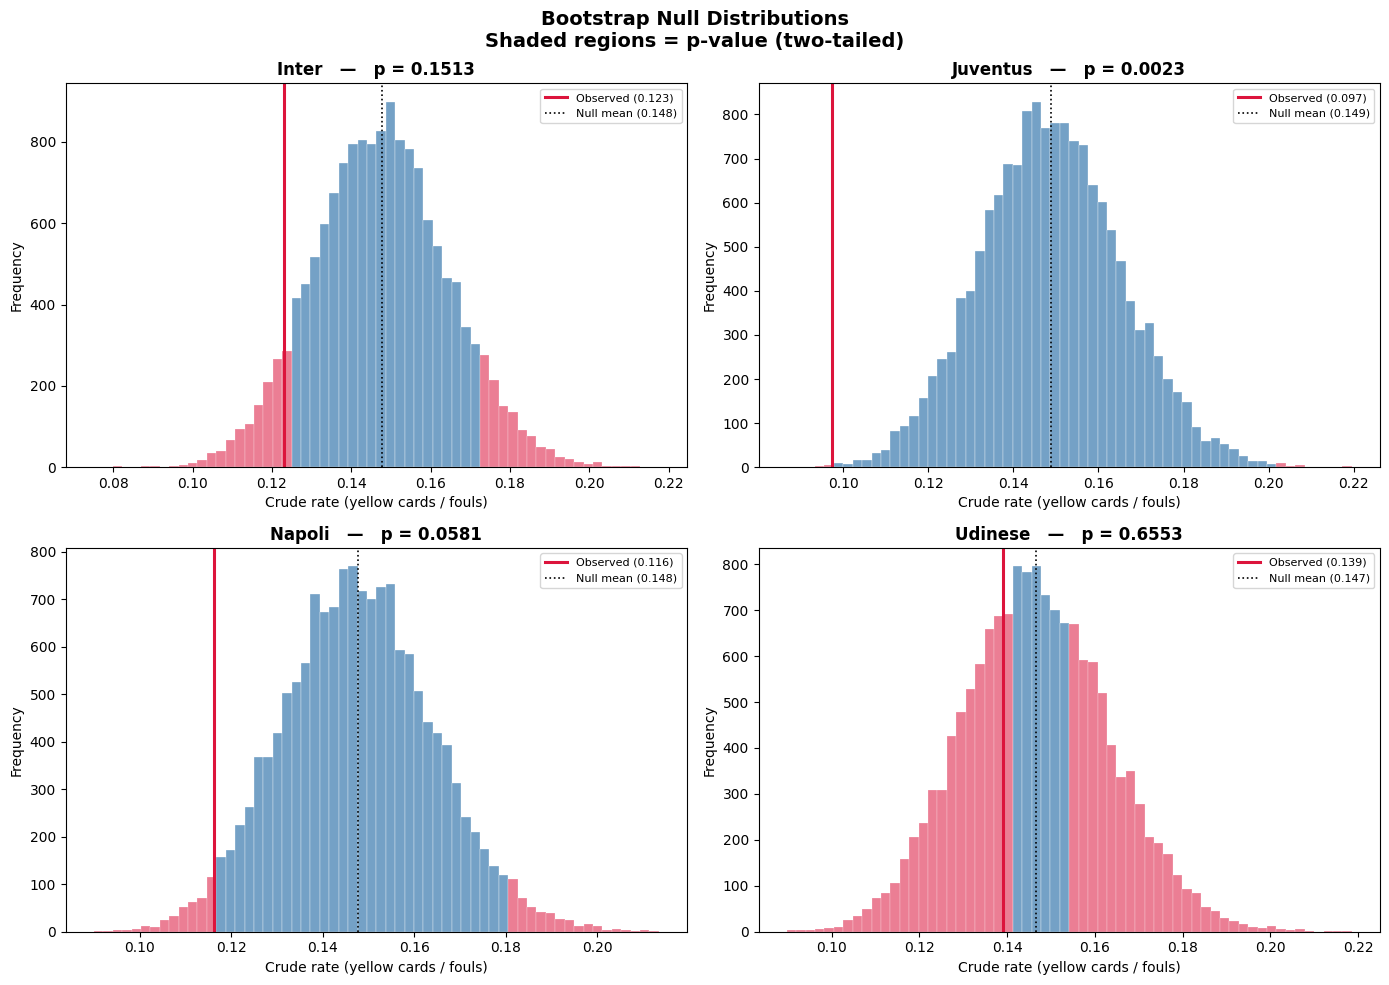

In [47]:
teams = ['Inter', 'Juventus', 'Napoli', 'Udinese']

fig = plot_bootstrap_grid(teams, ita_2526, n_bootstrap=15000, seed=42,ncols=2, palette='steelblue')

Delle quattro squadre prese in considerazione, solo la Juventus ha un p-value inferiore al 5%, e per la quale possiamo ritenere che presenti un valore significativamente diverso dalla media. Napoli e Inter, hanno dei valori di poco inferiori alla media ma la cui differenza rientra nella fluttuazione statistica. Per l'Udinese, il cui p-value e' piu' elevato rispetto alle altre tre, il valore osservato di 0.139 (circa 7.2 falli per cartellino giallo) si trova piu' al centro della curva della distribuzione.

Prima delle conclusioni, una piccola nota a margine. La media della distribuzione Nulla (ossia di tutte le squadre ad eccezione di quella con cui si fa il confronto) risulta diversa in ogni grafico. Questo e' dovuto a due fattori: quando si calcola la media delle rimanenti squadre, si tolgono dal conto i dati della squadra con la quale si fa il confronto. Inoltre, stiamo simulando dei dati: la media potra' essere diversa a seconda dei dati simulati, anche se con 15000 campionamenti, le differenze saranno minime.

# Conclusioni

Siamo arrivati alle conclusioni. Come passa velocemente il tempo quando ci si diverte. 

Quindi l'affermazione secondo la quale il dato dell'Inter rappresenterebbe un outlier per quanto riguarda il numero di cartellini gialli per falli commessi, non ha un riscontro statistico. Abbiamo fatto tutti i test possibili e immaginabili, e nessuno di questi suggerisce che lo sia (in un altro notebook della serie ho anche considerato  altri test e tutti concordano).

Significa forse che il professor Siciliano ha sbagliato? Quando si fanno analisi statistiche, bisogna sempre agire con cautela e pronti ad essere smentiti dai dati. La vera conclusione che posso dare e' che:

> *"Partendo dai dati che ho raccolto sulle prime 30 giornate del campionato di Serie A, il rapporto tra numero di cartellini gialli e falli commessi dall'Inter non e' statisticamente diverso da quello delle altre squadre."* 

Se anche avessimo trovato un risultato statisticamente fuori media, come nel caso della Juve, cosa possiamo concludere? Con i dati che abbiamo usato, ben poco. I test che abbiamo usato ci dicono che c'e' una differenza, ma non ci spiegano il perche' di questa differenza. Se volessimo investigare, dovremmo usare piu' dati, fare ulteriori ipotesi e poi testarle. Ma a molti piace pensare che, quando si tratta della Juventus, c'e' comunque qualcosa sotto.

Abbiamo usato diversi modelli, da quelli piu' semplici a quelli piu' complessi e precisi, e la conclusione e' quella. Se c'e' un errore, puo' essere dovuto ai dati raccolti, ad esempio. Quando si fanno analisi statistiche, sarebbe sempre opportuno dichiarare a priori da dove si prendono i dati, studiarli per capire se possono essere di buona qualita', fare ipotesi sulla loro distribuzione e quindi applicare i test statistici che possono dare i risultati migliori possibili. Se tutto questo viene fatto in maniera corretta, le conclusioni non possono che essere accettate. Anche quando possono non piacerci. 